<a href="https://colab.research.google.com/github/JuanCarlosAL91/deep-learning-2-TdeA/blob/main/Guia_12_Analisis_Sentimiento_Transformers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AVISO LEGAL — PROPIEDAD INTELECTUAL

Este material es propiedad intelectual exclusiva de Julián David Flórez Sánchez (LinkedIn). Todos los derechos reservados. Queda terminantemente prohibida su copia, reproducción, distribución, adaptación o uso por cualquier persona natural o jurídica, pública o privada, sin autorización expresa y escrita del autor. El incumplimiento de esta disposición acarrea las sanciones civiles y penales previstas en la Ley 23 de 1982, la Decisión Andina 351 de 1993, los artículos 270-272 del Código Penal Colombiano y los tratados internacionales de propiedad intelectual aplicables. Para solicitar autorización: linkedin.com/in/julianflorezdata

# Guia 12: Analisis de Sentimiento Avanzado con Transformers

## Electiva II - Deep Learning | Tecnologico de Antioquia

---

### Objetivo de aprendizaje

Aplicar tecnicas avanzadas de **analisis de sentimiento multiclase** con Transformers, aprender a **manejar datos desbalanceados**, utilizar **metricas avanzadas** de evaluacion (F1 macro/weighted, precision, recall) e **interpretar** las decisiones del modelo mediante attention weights.

### Conceptos nuevos en esta guia

| Concepto | Descripcion |
|----------|-------------|
| **Analisis de sentimiento multiclase** | Clasificacion en mas de 2 clases: muy negativo, negativo, neutro, positivo, muy positivo |
| **Datos desbalanceados** | Cuando unas clases tienen muchos mas ejemplos que otras |
| **Class weights** | Penalizar mas los errores en clases minoritarias durante el entrenamiento |
| **Oversampling** | Duplicar ejemplos de clases minoritarias para equilibrar el dataset |
| **Precision** | De lo que el modelo predijo como clase X, que proporcion realmente era clase X |
| **Recall** | De lo que realmente era clase X, que proporcion el modelo encontro correctamente |
| **F1-score** | Media armonica de precision y recall |
| **F1 macro vs weighted** | Macro: promedio simple por clase. Weighted: ponderado por frecuencia de clase |
| **Attention weights** | Pesos que indican que palabras "mira" el modelo para tomar su decision |
| **Interpretabilidad** | Capacidad de entender POR QUE un modelo tomo una decision |
| **Modelos multilingues** | Modelos entrenados en multiples idiomas simultaneamente |

### Prerrequisito
- **Guia 11:** Clasificacion de Texto con Hugging Face Transformers (BETO, fine-tuning, pipelines)

### Duracion estimada: 3 horas

### Entorno: Google Colab con GPU (OBLIGATORIO)

> **IMPORTANTE - Activar GPU T4:**
> 1. En el menu de Colab, ve a `Entorno de ejecucion` > `Cambiar tipo de entorno de ejecucion`
> 2. En **Acelerador por hardware**, selecciona **GPU T4**
> 3. Haz clic en **Guardar**
> 4. Verifica ejecutando la celda de verificacion de GPU mas abajo

---

> **Aviso de evaluacion** ✍️: Las preguntas marcadas con ✍️ deben responderse de forma individual. Estas respuestas seran parte de la evaluacion del micro. Responde con tus propias palabras, demostrando comprension profunda de los conceptos.

---

## 1. Configuracion del Entorno

Instalamos las librerias necesarias e importamos todos los modulos que usaremos a lo largo de la guia.

In [1]:
# Instalacion de librerias necesarias
!pip install transformers datasets accelerate seaborn -q

In [2]:
# Importaciones principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Hugging Face
from transformers import (
    pipeline,
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)
from datasets import Dataset

# Scikit-learn para evaluacion y manejo de datos
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)
from sklearn.utils.class_weight import compute_class_weight

# Configuracion de graficos
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('Todas las importaciones completadas exitosamente')

Todas las importaciones completadas exitosamente


In [3]:
# Verificacion de GPU - OBLIGATORIO
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'GPU disponible: {torch.cuda.get_device_name(0)}')
    print(f'Memoria GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    device = torch.device('cpu')
    print('ADVERTENCIA: No se detecto GPU.')
    print('Ve a Entorno de ejecucion > Cambiar tipo de entorno > GPU T4')
    print('El fine-tuning sera MUY lento sin GPU.')

print(f'Dispositivo seleccionado: {device}')

GPU disponible: Tesla T4
Memoria GPU: 15.6 GB
Dispositivo seleccionado: cuda


In [4]:
# Fijar semillas para reproducibilidad
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print(f'Semilla fijada: {SEED}')

Semilla fijada: 42


---

## 2. Marco Teorico

### 2.1 Analisis de sentimiento: Mas alla de positivo/negativo

En la Guia 11 trabajamos con clasificacion de texto en 3 clases (positivo, negativo, neutro). En la realidad, el sentimiento es mucho mas **granular**. Cuando lees una resena, puedes distinguir entre:

- **Muy negativo**: "Pesima experiencia, la peor de mi vida, jamas volvere" (enojo fuerte)
- **Negativo**: "No me gusto mucho, esperaba algo mejor" (decepcion moderada)
- **Neutro**: "El producto llego en la fecha indicada" (sin carga emocional)
- **Positivo**: "Buen producto, estoy contento con la compra" (satisfaccion moderada)
- **Muy positivo**: "Estoy absolutamente encantado, es lo mejor que he comprado!" (entusiasmo fuerte)

Esta clasificacion en **5 niveles** es mucho mas util en aplicaciones reales. Por ejemplo, un sistema de atencion al cliente necesita distinguir entre un cliente ligeramente insatisfecho (negativo) y uno furioso (muy negativo) para priorizar respuestas.

### 2.2 El problema del desbalance de clases

En datos reales, las clases **casi nunca** estan equilibradas. Por ejemplo, en resenas de productos:
- La mayoria de personas deja resenas neutras o positivas
- Pocas personas escriben resenas extremas (muy positivo o muy negativo)
- Las resenas negativas son mas comunes que las muy negativas

Esto crea un **desbalance de clases**, y es uno de los problemas mas comunes y peligrosos en machine learning.

#### ¿Por que es peligroso?

Imagina un dataset con esta distribucion:
- Neutro: 80 ejemplos (32%)
- Positivo: 60 ejemplos (24%)
- Negativo: 60 ejemplos (24%)
- Muy positivo: 30 ejemplos (12%)
- Muy negativo: 20 ejemplos (8%)

Un modelo "tramposo" podria simplemente **predecir siempre "neutro"** y obtener un 32% de accuracy. Pero peor aun, un modelo real tiende a **ignorar las clases minoritarias** porque equivocarse en ellas "cuesta poco" en terminos de loss global.

**El resultado**: el modelo parece funcionar bien segun accuracy, pero **falla completamente** en las clases que mas nos interesan (como detectar clientes muy insatisfechos).

### 2.3 Tecnicas para manejar datos desbalanceados

Existen varias estrategias para combatir el desbalance:

#### a) Class Weights (Pesos de clase)

La idea es simple pero efectiva: **penalizar mas los errores en las clases minoritarias**. Si el modelo se equivoca al clasificar un texto "muy_negativo" (clase rara), la penalizacion es mayor que si se equivoca en "neutro" (clase comun).

Los pesos se calculan **inversamente proporcionales a la frecuencia**:

$$w_c = \frac{N}{K \times n_c}$$

Donde:
- $w_c$ = peso de la clase $c$
- $N$ = numero total de muestras
- $K$ = numero de clases
- $n_c$ = numero de muestras de la clase $c$

**Ejemplo numerico**: Con 250 muestras y 5 clases:
- Clase "neutro" (80 muestras): $w = \frac{250}{5 \times 80} = 0.625$ (se penaliza menos)
- Clase "muy_negativo" (20 muestras): $w = \frac{250}{5 \times 20} = 2.5$ (se penaliza 4 veces mas)

Esto hace que el modelo "preste mas atencion" a las clases raras.

#### b) Oversampling (Sobremuestreo)

Consiste en **duplicar ejemplos de las clases minoritarias** hasta que todas las clases tengan aproximadamente la misma cantidad de datos. Es como si le dieras al modelo mas oportunidades de ver los ejemplos raros.

#### c) Undersampling (Submuestreo)

Lo opuesto: **eliminar ejemplos de las clases mayoritarias** para equilibrar. El riesgo es perder informacion valiosa.

#### d) SMOTE para texto

Generar ejemplos sinteticos de clases minoritarias. Para texto esto es mas complejo que para datos numericos, pero se puede hacer en el espacio de embeddings.

### 2.4 Metricas avanzadas de evaluacion

Accuracy no es suficiente cuando hay desbalance. Necesitamos metricas que evaluen **cada clase por separado**.

#### Precision (Exactitud)

> De todo lo que el modelo **predijo** como clase X, ¿cuanto **realmente** era clase X?

$$\text{Precision}_c = \frac{\text{Verdaderos Positivos}_c}{\text{Verdaderos Positivos}_c + \text{Falsos Positivos}_c}$$

**Ejemplo numerico**: El modelo predijo 10 textos como "muy_negativo". De esos 10, solo 7 realmente eran "muy_negativo" y 3 eran de otras clases.

$$\text{Precision}_{\text{muy\_negativo}} = \frac{7}{7 + 3} = 0.70$$

**Interpretacion**: "Cuando el modelo dice que algo es muy negativo, tiene razon el 70% de las veces."

#### Recall (Sensibilidad / Cobertura)

> De todo lo que **realmente** era clase X, ¿cuanto **encontro** el modelo?

$$\text{Recall}_c = \frac{\text{Verdaderos Positivos}_c}{\text{Verdaderos Positivos}_c + \text{Falsos Negativos}_c}$$

**Ejemplo numerico**: Habia 20 textos realmente "muy_negativo" en el dataset. El modelo solo identifico 7 de ellos correctamente.

$$\text{Recall}_{\text{muy\_negativo}} = \frac{7}{20} = 0.35$$

**Interpretacion**: "De los textos realmente muy negativos, el modelo solo encuentra el 35%. Se le escapa el 65%."

#### F1-Score

La **media armonica** de precision y recall. Es mas estricta que el promedio simple: si uno de los dos es bajo, F1 tambien sera bajo.

$$F1_c = 2 \times \frac{\text{Precision}_c \times \text{Recall}_c}{\text{Precision}_c + \text{Recall}_c}$$

**Ejemplo**: Con precision=0.70 y recall=0.35:

$$F1_{\text{muy\_negativo}} = 2 \times \frac{0.70 \times 0.35}{0.70 + 0.35} = 2 \times \frac{0.245}{1.05} = 0.467$$

#### F1 Macro vs F1 Weighted

- **F1 Macro**: Promedio **simple** del F1 de cada clase. Trata todas las clases por igual, sin importar cuantas muestras tenga cada una. **Ideal cuando todas las clases son igual de importantes** (por ejemplo, detectar clientes muy insatisfechos es tan importante como detectar los satisfechos).

$$F1_{\text{macro}} = \frac{1}{K} \sum_{c=1}^{K} F1_c$$

- **F1 Weighted**: Promedio **ponderado** por el numero de muestras de cada clase. Da mas peso a las clases con mas datos. **Util cuando quieres reflejar el rendimiento "real" del modelo en la distribucion original de datos.**

$$F1_{\text{weighted}} = \sum_{c=1}^{K} \frac{n_c}{N} \times F1_c$$

**Ejemplo comparativo**:

| Clase | F1 | Muestras |
|-------|-----|----------|
| muy_negativo | 0.47 | 20 |
| negativo | 0.72 | 60 |
| neutro | 0.85 | 80 |
| positivo | 0.75 | 60 |
| muy_positivo | 0.55 | 30 |

$$F1_{\text{macro}} = \frac{0.47 + 0.72 + 0.85 + 0.75 + 0.55}{5} = 0.668$$

$$F1_{\text{weighted}} = \frac{20(0.47) + 60(0.72) + 80(0.85) + 60(0.75) + 30(0.55)}{250} = 0.729$$

Nota como F1 macro (0.668) es mas bajo que F1 weighted (0.729). Esto revela que el modelo funciona peor en las clases minoritarias, pero el F1 weighted "oculta" este problema al ponderar mas las clases mayoritarias.

**Regla practica**: Si te importan las clases raras, mira F1 macro. Si quieres el rendimiento global, mira F1 weighted.

### 2.5 Interpretabilidad de modelos

Una de las preguntas mas importantes en machine learning es: **¿POR QUE el modelo decidio eso?**

Imagina que tu modelo clasifica la resena "El servicio no fue tan malo" como "muy_negativo". Necesitas saber: ¿esta mirando las palabras correctas? ¿Se confundio con "malo"? ¿Ignoro el "no fue tan"?

#### Attention Weights (Pesos de atencion)

Los Transformers tienen una ventaja unica para interpretabilidad: los **attention weights** nos dicen que palabras "mira" el modelo al procesar cada token.

Si al clasificar "La comida estuvo **deliciosa** y el servicio **excelente**", el modelo pone alta atencion en "deliciosa" y "excelente", podemos confiar en que esta tomando la decision por las razones correctas.

Pero si pone alta atencion en "La" y "y", algo esta mal.

#### ¿Por que es importante la interpretabilidad?

1. **Confianza**: Antes de poner un modelo en produccion, necesitas verificar que decide por las razones correctas
2. **Debugging**: Si el modelo falla, los attention weights te ayudan a entender por que
3. **Sesgo**: Puedes detectar si el modelo tiene sesgos (por ejemplo, si siempre asocia ciertos nombres con sentimiento negativo)
4. **Regulacion**: En algunos dominios (medicina, finanzas), es obligatorio poder explicar las decisiones del modelo
5. **Mejora**: Entender que mira el modelo te da pistas de como mejorar los datos de entrenamiento

---

## 3. Carga y Exploracion de Datos

Trabajaremos con un dataset de **comentarios en espanol** sobre diversos temas (productos tecnologicos, servicio al cliente, transporte publico, comida, politica) con 5 niveles de sentimiento **intencionalmente desbalanceados**, simulando una distribucion real.

Las 5 clases y sus cantidades (desbalanceadas):
- **muy_negativo**: ~20 textos (clase minoritaria)
- **negativo**: ~60 textos
- **neutro**: ~80 textos (clase mayoritaria)
- **positivo**: ~60 textos
- **muy_positivo**: ~30 textos (clase minoritaria)

In [5]:
# =================================================================
# DATASET DESBALANCEADO DE SENTIMIENTO EN ESPANOL (5 clases)
# Temas: productos tecnologicos, servicio al cliente, transporte
#        publico, comida, politica
# =================================================================

# --- CLASE 0: MUY NEGATIVO (~20 textos) - Clase minoritaria ---
textos_muy_negativo = [
    # Productos tecnologicos
    'Este celular es la peor basura que he comprado en mi vida, no sirve para nada',
    'La laptop se dano a los dos dias, botenla a la basura, estafa total',
    'Los audifonos llegaron rotos y el vendedor jamas respondio, ladrones',
    'La tablet es un fraude completo, lenta, se apaga sola, pantalla horrible',
    'Perdi toda mi informacion por esta porqueria de disco duro, inaceptable',
    # Servicio al cliente
    'Llevo tres meses esperando mi reembolso y nadie me da respuesta, esto es un robo',
    'El peor servicio al cliente del mundo, groseros, incompetentes y mentirosos',
    'Me estafaron con la garantia, no cubren nada, son unos sinverguenzas',
    'La empresa es un asco total, nunca resuelven nada y se burlan del cliente',
    'Llame veinte veces y me colgaron en todas, esto deberia ser ilegal',
    # Transporte publico
    'El transporte publico en esta ciudad es una pesadilla absoluta, inhumano',
    'Casi me mato en ese bus destartalado sin frenos, deberian cerrarlo ya',
    'Los buses van tan llenos que es imposible respirar, es una tortura diaria',
    'El metro se dano tres veces esta semana, estoy harto de tanta incompetencia',
    # Comida
    'La comida tenia cucarachas, casi vomito, deberian cerrar ese restaurante',
    'Me intoxique gravemente por comer ahi, termine en urgencias, demanda segura',
    'La peor comida que he probado en mi vida, un insulto al paladar',
    # Politica
    'Este gobierno es el mas corrupto e inutil de toda la historia del pais',
    'Los politicos solo roban y mienten, el pais va directo al abismo',
    'Es indignante la corrupcion, mientras el pueblo sufre ellos se enriquecen',
]

# --- CLASE 1: NEGATIVO (~60 textos) ---
textos_negativo = [
    # Productos tecnologicos
    'El celular se calienta mucho cuando lo uso mas de media hora',
    'La camara del telefono no es tan buena como dicen en la publicidad',
    'La bateria dura muy poco, no me alcanza para un dia completo',
    'El cargador dejo de funcionar al mes, calidad bastante regular',
    'La pantalla tiene un pixel muerto que molesta bastante',
    'El procesador es lento para las aplicaciones que necesito',
    'El telefono se congela frecuentemente cuando abro varias apps',
    'La memoria interna se llena muy rapido, solo 32 gigas es insuficiente',
    'Las actualizaciones hacen que el celular funcione peor que antes',
    'El sonido de los parlantes es metalico y de baja calidad',
    'El reconocimiento facial falla mucho con poca luz',
    'El teclado del portatil es incomodo y las teclas son duras',
    # Servicio al cliente
    'El servicio de atencion al cliente es demasiado lento y poco eficiente',
    'Me pusieron en espera durante cuarenta minutos antes de atenderme',
    'El asesor no sabia resolver mi problema y me paso con otro que tampoco sabia',
    'La garantia no cubre lo que deberia, las condiciones son confusas',
    'Tuve que ir tres veces a la tienda para que me resolvieran el reclamo',
    'El proceso de devolucion es complicado y tedioso, muchos tramites',
    'No cumplen con los tiempos de entrega que prometen',
    'La respuesta por correo electronico tardo mas de una semana',
    'El chatbot no entiende nada y es imposible hablar con un humano',
    'Me cobraron de mas y el proceso de reclamacion fue largo y molesto',
    # Transporte publico
    'Los buses nunca llegan a tiempo, siempre hay que esperar demasiado',
    'El metro esta muy lleno en horas pico, es bastante incomodo',
    'Las rutas de los buses no cubren bien mi zona, toca caminar mucho',
    'El aire acondicionado del bus no funciona y el calor es insoportable',
    'Los conductores manejan muy rapido y de forma imprudente',
    'La tarjeta del metro falla frecuentemente en los torniquetes',
    'Las estaciones estan sucias y mal mantenidas',
    'El transporte sube de precio constantemente sin mejorar el servicio',
    'Los horarios del metro no se cumplen los fines de semana',
    'Los buses viejos contaminan mucho y hacen demasiado ruido',
    # Comida
    'La comida estaba fria cuando llego el domicilio, no la calentaron',
    'El plato no se parecia en nada a la foto del menu, decepcionante',
    'Las porciones son muy pequenas para el precio que cobran',
    'La ensalada tenia la lechuga marchita, no estaba fresca',
    'La sopa estaba demasiado salada, no se podia comer bien',
    'El servicio en el restaurante fue lento, tardaron mucho',
    'La pizza llego con los ingredientes equivocados',
    'El postre era demasiado dulce y empalagoso para mi gusto',
    'La carne estaba un poco dura, le falto coccion',
    'El jugo natural no sabia tan natural que digamos',
    'El pan estaba un poco seco, como del dia anterior',
    'La hamburguesa era muy grasosa y pesada',
    # Politica
    'Las promesas de campana nunca se cumplen, ya es costumbre',
    'La reforma tributaria va a afectar a la clase media negativamente',
    'Los hospitales publicos siguen con las mismas deficiencias de siempre',
    'La educacion publica necesita mas inversion, esta descuidada',
    'Los subsidios no llegan a quienes realmente los necesitan',
    'La infraestructura de las vias es deficiente en muchas regiones',
    'No estoy de acuerdo con la nueva ley de impuestos, nos perjudica',
    'La inseguridad ha aumentado y no se ven resultados de las autoridades',
    'Los servicios publicos son caros y de mala calidad en varias zonas',
    'La burocracia del gobierno hace que todo sea lento e ineficiente',
    'El desempleo sigue siendo un problema grave sin solucion clara',
    'Las pensiones son insuficientes para vivir dignamente',
    'El internet del operador es pesimo, se cae a cada rato',
    'La aplicacion tiene muchos errores y se cierra sola constantemente',
    'El envio tardo tres semanas cuando prometieron cinco dias habiles',
    'Los precios subieron mucho y la calidad bajo notablemente',
]

print(f'Textos muy_negativo: {len(textos_muy_negativo)}')
print(f'Textos negativo: {len(textos_negativo)}')

Textos muy_negativo: 20
Textos negativo: 60


In [6]:
# --- CLASE 2: NEUTRO (~80 textos) - Clase mayoritaria ---
textos_neutro = [
    # Productos tecnologicos
    'El celular tiene pantalla de seis punto cinco pulgadas y procesador Snapdragon',
    'La laptop viene con sistema operativo Windows once preinstalado',
    'Los audifonos tienen conectividad Bluetooth cinco punto cero',
    'La tablet tiene una memoria RAM de cuatro gigabytes',
    'El disco duro externo tiene capacidad de un terabyte',
    'El telefono esta disponible en tres colores: negro, blanco y azul',
    'La camara tiene resolucion de cuarenta y ocho megapixeles',
    'El cargador es de tipo C y carga rapida de treinta vatios',
    'La impresora funciona con wifi y tambien con cable USB',
    'El monitor tiene resolucion cuatro K y panel IPS',
    'Los parlantes tienen potencia de veinte vatios RMS',
    'La tarjeta grafica es una RTX cuatro mil sesenta',
    'El router tiene cobertura para un area de cien metros cuadrados',
    'El mouse es inalambrico y usa una pila doble A',
    'El teclado tiene retroiluminacion RGB y es mecanico',
    # Servicio al cliente
    'El horario de atencion es de lunes a viernes de ocho a cinco',
    'Para hacer un reclamo hay que llenar el formulario en linea',
    'La garantia cubre defectos de fabrica durante un ano',
    'El numero de servicio al cliente es el 018000 seguido de seis digitos',
    'La sucursal principal queda en el centro de la ciudad',
    'Los domicilios se realizan en un plazo de tres a cinco dias habiles',
    'La empresa tiene sedes en Bogota, Medellin y Cali',
    'Para cambios de producto se requiere la factura original',
    'El chat de soporte esta disponible las veinticuatro horas',
    'La politica de devolucion aplica dentro de los treinta dias de la compra',
    'Se puede pagar con tarjeta de credito, debito o efectivo',
    'Los asesores comerciales atienden por orden de llegada',
    'La empresa tiene mas de cinco mil empleados en el pais',
    'El centro de distribucion esta ubicado en Bogota',
    'Las facturas electronicas se envian al correo registrado',
    # Transporte publico
    'El metro opera de lunes a sabado de cinco de la manana a once de la noche',
    'La tarifa del bus urbano es de dos mil ochocientos pesos',
    'Hay estaciones de bicicletas publicas cerca de las estaciones del metro',
    'La ruta del bus pasa cada quince minutos en horas normales',
    'El sistema de transporte tiene cobertura en toda el area metropolitana',
    'Los buses articulados tienen capacidad para ciento sesenta pasajeros',
    'La estacion de transferencia conecta tres lineas diferentes',
    'El horario de los buses alimentadores cambia los domingos',
    'Se puede recargar la tarjeta en cualquier estacion o punto autorizado',
    'El sistema de transporte moviliza mas de dos millones de personas al dia',
    'Las rutas estan identificadas con numeros y colores diferentes',
    'Los paraderos estan senalizados con el mapa de la ruta',
    'El tiempo estimado de viaje del centro al sur es de cuarenta minutos',
    'La flota de buses se renueva cada ocho anos aproximadamente',
    'Las estaciones tienen maquinas automaticas para recarga',
    # Comida
    'El restaurante abre de martes a domingo a partir del mediodia',
    'El menu tiene opciones de carne, pollo, pescado y vegetarianas',
    'El almuerzo ejecutivo incluye sopa, plato fuerte, jugo y postre',
    'El plato del dia cuesta quince mil pesos con bebida incluida',
    'Aceptan pagos con tarjeta y tambien efectivo',
    'El restaurante tiene capacidad para sesenta personas',
    'Tienen servicio de domicilio por las principales aplicaciones',
    'La carta esta disponible en espanol y en ingles',
    'El horario de atencion del restaurante es de once a nueve',
    'Ofrecen menu especial para ninos menores de doce anos',
    'El local esta ubicado en la zona gastronomica del barrio',
    'El chef principal estudio en una escuela de cocina francesa',
    'Hacen descuento del diez por ciento para grupos de mas de ocho personas',
    'El restaurante tiene una calificacion de cuatro punto dos en Google',
    'Tienen terraza al aire libre y salon cerrado con aire acondicionado',
    # Politica
    'Las elecciones presidenciales se realizan cada cuatro anos',
    'El congreso esta compuesto por senado y camara de representantes',
    'El presupuesto nacional para educacion es de cincuenta billones de pesos',
    'La reforma fue aprobada con ciento veinte votos a favor',
    'El plan de desarrollo contempla inversiones en infraestructura',
    'Las alcaldias municipales administran los recursos locales',
    'El proceso electoral es supervisado por la registraduria',
    'Colombia tiene treinta y dos departamentos y un distrito capital',
    'La constitucion fue reformada en mil novecientos noventa y uno',
    'El salario minimo se ajusta anualmente segun la inflacion',
    'Los impuestos se declaran en los primeros meses del ano',
    'El sistema de salud tiene regimen contributivo y subsidiado',
    'La corte constitucional revisa la legalidad de las leyes',
    'Las gobernaciones coordinan los planes departamentales',
    'El censo poblacional se realiza cada diez anos aproximadamente',
    'El establecimiento fue inaugurado hace tres anos en esta ubicacion',
    'Las mesas tienen capacidad para cuatro personas cada una',
    'El horario de domicilios es diferente al horario del local',
    'La empresa tiene presencia en cinco ciudades del pais',
    'Los productos se fabrican en la planta de la zona industrial',
]

print(f'Textos neutro: {len(textos_neutro)}')

Textos neutro: 80


In [7]:
# --- CLASE 3: POSITIVO (~60 textos) ---
textos_positivo = [
    # Productos tecnologicos
    'El celular tiene buena camara y la bateria dura bastante bien',
    'La laptop funciona bien para trabajar y hacer presentaciones',
    'Los audifonos tienen buen sonido y son comodos para usar todo el dia',
    'La tablet es rapida y la pantalla se ve muy bien para leer',
    'El disco duro es confiable y transfiere archivos rapido',
    'El telefono tiene un diseno bonito y es facil de usar',
    'La camara frontal toma buenas selfies con buena iluminacion',
    'El cargador rapido es muy practico, carga en menos de una hora',
    'La impresora es facil de configurar y funciona bien',
    'El monitor tiene buenos colores y buen tamano para trabajar',
    'Los parlantes suenan bien y se conectan facil por Bluetooth',
    'El mouse es ergonomico y responde bien para el trabajo diario',
    # Servicio al cliente
    'La asesora fue amable y me ayudo a resolver mi problema',
    'El proceso de garantia fue relativamente rapido y sin complicaciones',
    'Me devolvieron el dinero sin muchos inconvenientes',
    'El chat de soporte me respondio en pocos minutos',
    'La entrega fue puntual y el producto llego bien empacado',
    'El asesor me explico bien las opciones disponibles',
    'Pude hacer el cambio de producto sin problemas',
    'La atencion en la tienda fue buena y organizada',
    'El proceso de compra en linea es facil y seguro',
    'Me llamaron para confirmar que todo estuviera bien con mi pedido',
    # Transporte publico
    'El metro es una buena opcion para moverse por la ciudad',
    'Los buses alimentadores cubren bien las zonas residenciales',
    'La tarjeta recargable es practica y facil de usar',
    'Las estaciones son accesibles para personas con discapacidad',
    'El sistema de transporte ha mejorado bastante en los ultimos anos',
    'Los buses nuevos son mas comodos y tienen aire acondicionado',
    'La aplicacion del metro muestra los horarios en tiempo real',
    'El viaje en metro es mas rapido que en carro por el trafico',
    'Las ciclorrutas complementan bien el sistema de transporte',
    'Los conductores generalmente son respetuosos y profesionales',
    # Comida
    'La comida esta bien preparada y las porciones son adecuadas',
    'El restaurante tiene un ambiente agradable para comer en familia',
    'El servicio es atento y el mesero nos asesoro bien con el menu',
    'La sopa del dia estaba rica y calientica',
    'El jugo natural estaba fresco y bien preparado',
    'El plato ejecutivo es buena opcion y tiene buen precio',
    'Los postres son ricos y tienen buena presentacion',
    'La comida llego rapido por domicilio y en buen estado',
    'Las arepas con queso estaban buenas y recien hechas',
    'El cafe esta bien preparado y tienen buenas opciones de panaderia',
    'El arroz con pollo tenia buen sabor y estaba bien servido',
    'La atencion del mesero fue cordial y eficiente',
    # Politica
    'El nuevo parque del barrio quedo bonito y bien equipado',
    'El programa de alimentacion escolar beneficia a muchos ninos',
    'La nueva via ha reducido los tiempos de viaje entre las ciudades',
    'El sistema de becas esta ayudando a mas jovenes a estudiar',
    'Los centros de salud del barrio han mejorado su atencion',
    'El programa de vivienda ha beneficiado a varias familias',
    'Las bibliotecas publicas ofrecen buenos programas de lectura',
    'La reforestacion del parque natural es una buena iniciativa',
    'El wifi gratuito en los parques es una buena idea',
    'Los programas culturales de la alcaldia son variados y accesibles',
    'La nueva cicloruta facilita la movilidad de los ciclistas',
    'Las jornadas de vacunacion estan bien organizadas',
    'El soporte tecnico me ayudo rapidamente a solucionar el problema',
    'La aplicacion es intuitiva y facil de usar desde el primer momento',
    'El producto tiene buena relacion calidad precio, estoy satisfecho',
    'Los tiempos de entrega son razonables y el empaque es bueno',
]

# --- CLASE 4: MUY POSITIVO (~30 textos) - Clase minoritaria ---
textos_muy_positivo = [
    # Productos tecnologicos
    'Este celular es una maravilla absoluta, el mejor que he tenido en mi vida!',
    'La laptop es espectacular, rapida como un rayo y la pantalla es increible',
    'Estos audifonos son una joya, el sonido es perfecto, estoy enamorado',
    'La tablet es impresionante, supero todas mis expectativas por mucho',
    'El mejor disco duro del mercado, velocidad y capacidad excepcionales',
    'Este telefono es una obra maestra de la tecnologia, simplemente perfecto',
    # Servicio al cliente
    'Atencion de primera clase, me trataron como rey, servicio impecable!',
    'Increible servicio postventa, resolvieron todo al instante, felicitaciones!',
    'La mejor experiencia de compra de mi vida, todo perfecto de principio a fin',
    'El equipo de soporte es excepcional, profesionales de verdad, los mejores!',
    'Estoy encantado con la atencion, superaron todas mis expectativas',
    # Transporte publico
    'El nuevo metro es un orgullo para la ciudad, moderno y eficiente, maravilloso!',
    'El sistema de transporte masivo es de clase mundial, estoy impresionado',
    'Las nuevas estaciones son espectaculares, bonitas, limpias y funcionales',
    'El metro cable es una genialidad, transformo completamente los barrios',
    'El tranvia es hermoso y puntual, lo mejor que le ha pasado a la ciudad',
    # Comida
    'La mejor comida que he probado en toda mi vida, una experiencia sublime!',
    'Este restaurante es una joya escondida, absolutamente todo es perfecto',
    'El chef es un genio, cada plato es una obra de arte culinaria',
    'La experiencia gastronomica mas increible, de talla mundial sin exagerar',
    'Estoy fascinado con la calidad, el mejor restaurante de Colombia sin duda',
    'Los postres son de otro planeta, nunca habia probado algo tan delicioso',
    # Politica
    'El programa de paz es lo mejor que le ha pasado al pais, historico!',
    'La transformacion del barrio es impresionante, gracias al plan de gobierno',
    'El plan de educacion gratuita es extraordinario, un cambio historico',
    'La inversion en ciencia y tecnologia esta dando resultados espectaculares',
    'El sistema de becas universitarias es lo mejor, ha cambiado miles de vidas',
    'La nueva politica ambiental es un ejemplo para toda Latinoamerica',
    'El programa de emprendimiento es fantastico, ha creado miles de empleos',
    'La inversion en salud publica ha sido la mejor decision del gobierno',
]

print(f'Textos positivo: {len(textos_positivo)}')
print(f'Textos muy_positivo: {len(textos_muy_positivo)}')

Textos positivo: 60
Textos muy_positivo: 30


In [8]:
# Combinar todos los textos y crear etiquetas
# 0: muy_negativo, 1: negativo, 2: neutro, 3: positivo, 4: muy_positivo

textos = (textos_muy_negativo + textos_negativo + textos_neutro +
          textos_positivo + textos_muy_positivo)

etiquetas = ([0] * len(textos_muy_negativo) +
             [1] * len(textos_negativo) +
             [2] * len(textos_neutro) +
             [3] * len(textos_positivo) +
             [4] * len(textos_muy_positivo))

# Mapa de clases
id2label = {
    0: 'muy_negativo',
    1: 'negativo',
    2: 'neutro',
    3: 'positivo',
    4: 'muy_positivo'
}
label2id = {v: k for k, v in id2label.items()}

# Crear DataFrame para exploracion
df = pd.DataFrame({'texto': textos, 'etiqueta': etiquetas})
df['clase'] = df['etiqueta'].map(id2label)
df['longitud'] = df['texto'].apply(len)
df['num_palabras'] = df['texto'].apply(lambda x: len(x.split()))

print('=' * 70)
print('RESUMEN DEL DATASET')
print('=' * 70)
print(f'Total de textos: {len(textos)}')
print(f'Numero de clases: {len(id2label)}')
print()
print('Distribucion de clases:')
for clase_id in sorted(id2label.keys()):
    nombre = id2label[clase_id]
    cantidad = etiquetas.count(clase_id)
    porcentaje = cantidad / len(etiquetas) * 100
    barra = '█' * int(porcentaje)
    print(f'  {nombre:15s}: {cantidad:3d} ({porcentaje:5.1f}%) {barra}')

RESUMEN DEL DATASET
Total de textos: 250
Numero de clases: 5

Distribucion de clases:
  muy_negativo   :  20 (  8.0%) ████████
  negativo       :  60 ( 24.0%) ████████████████████████
  neutro         :  80 ( 32.0%) ████████████████████████████████
  positivo       :  60 ( 24.0%) ████████████████████████
  muy_positivo   :  30 ( 12.0%) ████████████


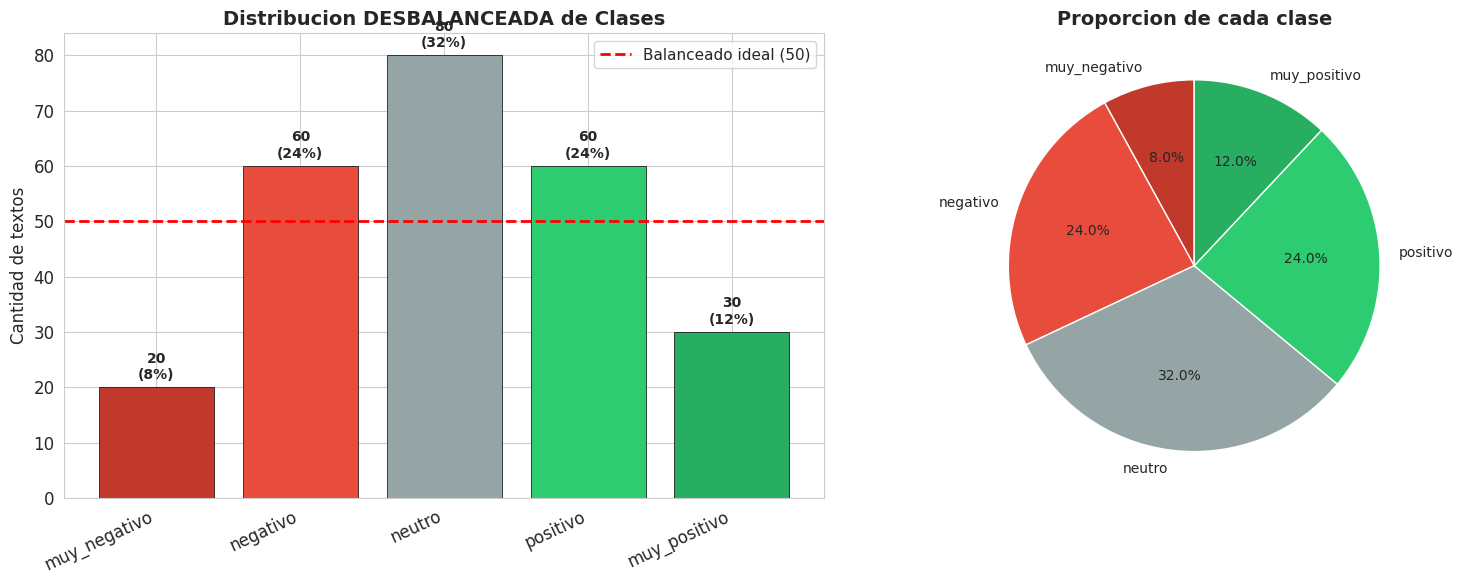


Nota: Observa como la clase "neutro" tiene 4 veces mas datos que "muy_negativo".
Un modelo naive que siempre prediga "neutro" tendria accuracy alta pero F1 macro bajo.

Accuracy de un modelo que siempre predice "neutro": 32.0%


In [9]:
# Visualizar el DESBALANCE de clases
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grafico de barras con distribucion desbalanceada
conteo = df['clase'].value_counts().reindex(['muy_negativo', 'negativo', 'neutro', 'positivo', 'muy_positivo'])
colores = ['#c0392b', '#e74c3c', '#95a5a6', '#2ecc71', '#27ae60']

barras = axes[0].bar(range(len(conteo)), conteo.values, color=colores, edgecolor='black', linewidth=0.5)
axes[0].set_xticks(range(len(conteo)))
axes[0].set_xticklabels(conteo.index, rotation=25, ha='right')
axes[0].set_title('Distribucion DESBALANCEADA de Clases', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Cantidad de textos')

# Anotar las barras con cantidad y porcentaje
for i, (barra, valor) in enumerate(zip(barras, conteo.values)):
    porcentaje = valor / len(df) * 100
    axes[0].text(barra.get_x() + barra.get_width()/2., barra.get_height() + 1,
                f'{valor}\n({porcentaje:.0f}%)', ha='center', va='bottom',
                fontweight='bold', fontsize=10)

# Linea punteada mostrando que seria una distribucion balanceada
equilibrado = len(df) / len(id2label)
axes[0].axhline(y=equilibrado, color='red', linestyle='--', linewidth=2,
               label=f'Balanceado ideal ({equilibrado:.0f})')
axes[0].legend(fontsize=11)

# Grafico de pie
axes[1].pie(conteo.values, labels=conteo.index, colors=colores,
           autopct='%1.1f%%', startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Proporcion de cada clase', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print('\nNota: Observa como la clase "neutro" tiene 4 veces mas datos que "muy_negativo".')
print('Un modelo naive que siempre prediga "neutro" tendria accuracy alta pero F1 macro bajo.')
print(f'\nAccuracy de un modelo que siempre predice "neutro": {len(textos_neutro)/len(textos)*100:.1f}%')

In [10]:
# Dividir en entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    textos, etiquetas,
    test_size=0.2,
    random_state=SEED,
    stratify=etiquetas  # Mantener proporcion de clases
)

print(f'Datos de entrenamiento: {len(X_train)}')
print(f'Datos de prueba: {len(X_test)}')
print()
print('Distribucion en ENTRENAMIENTO:')
for clase_id in sorted(id2label.keys()):
    count = y_train.count(clase_id)
    print(f'  {id2label[clase_id]:15s}: {count}')
print()
print('Distribucion en PRUEBA:')
for clase_id in sorted(id2label.keys()):
    count = y_test.count(clase_id)
    print(f'  {id2label[clase_id]:15s}: {count}')

Datos de entrenamiento: 200
Datos de prueba: 50

Distribucion en ENTRENAMIENTO:
  muy_negativo   : 16
  negativo       : 48
  neutro         : 64
  positivo       : 48
  muy_positivo   : 24

Distribucion en PRUEBA:
  muy_negativo   : 4
  negativo       : 12
  neutro         : 16
  positivo       : 12
  muy_positivo   : 6


In [11]:
# Cargar tokenizer y preparar datos para BETO
nombre_modelo = 'dccuchile/bert-base-spanish-wwm-cased'
tokenizer = AutoTokenizer.from_pretrained(nombre_modelo)

print(f'Tokenizer cargado: {nombre_modelo}')
print(f'Vocabulario: {tokenizer.vocab_size} tokens')

# Funcion para tokenizar y crear datasets de Hugging Face
def tokenizar_datos(textos, etiquetas):
    """Tokeniza textos y crea un Dataset de Hugging Face."""
    encodings = tokenizer(
        textos,
        truncation=True,
        padding='max_length',
        max_length=128,
        return_tensors=None
    )
    dataset = Dataset.from_dict({
        'input_ids': encodings['input_ids'],
        'attention_mask': encodings['attention_mask'],
        'labels': etiquetas
    })
    return dataset

dataset_train = tokenizar_datos(X_train, y_train)
dataset_test = tokenizar_datos(X_test, y_test)

print(f'\nDataset entrenamiento: {dataset_train}')
print(f'Dataset prueba: {dataset_test}')

config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/242k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/480k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

Tokenizer cargado: dccuchile/bert-base-spanish-wwm-cased
Vocabulario: 31002 tokens

Dataset entrenamiento: Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 200
})
Dataset prueba: Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 50
})


---

## 4. Experimentacion Guiada

Realizaremos 7 experimentos progresivos para explorar el analisis de sentimiento avanzado, el manejo de datos desbalanceados, las metricas avanzadas y la interpretabilidad.

---

### Experimento 1: Baseline con datos desbalanceados (sin tratar)

Primero entrenaremos BETO **directamente** con los datos desbalanceados, sin aplicar ninguna tecnica de correccion. Esto nos dara un **baseline** para comparar.

La hipotesis es que el modelo tendra un accuracy aparentemente bueno, pero al mirar el F1 **por clase**, las clases minoritarias (muy_negativo y muy_positivo) tendran un rendimiento bajo.

In [12]:
# ===================================================
# EXPERIMENTO 1: BASELINE - BETO sin class weights
# ===================================================

# Cargar BETO con cabeza de clasificacion para 5 clases
modelo_baseline = AutoModelForSequenceClassification.from_pretrained(
    nombre_modelo,
    num_labels=5,
    id2label=id2label,
    label2id=label2id
)

# Funcion de metricas detallada
def calcular_metricas(eval_pred):
    """Calcula accuracy, F1 macro y F1 weighted."""
    predicciones, etiquetas_reales = eval_pred
    predicciones = np.argmax(predicciones, axis=-1)
    acc = accuracy_score(etiquetas_reales, predicciones)
    f1_mac = f1_score(etiquetas_reales, predicciones, average='macro')
    f1_wei = f1_score(etiquetas_reales, predicciones, average='weighted')
    return {'accuracy': acc, 'f1_macro': f1_mac, 'f1_weighted': f1_wei}

# Argumentos de entrenamiento
args_baseline = TrainingArguments(
    output_dir='./resultados_baseline',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    seed=SEED,
    report_to='none',
)

# Crear Trainer y entrenar
trainer_baseline = Trainer(
    model=modelo_baseline,
    args=args_baseline,
    train_dataset=dataset_train,
    eval_dataset=dataset_test,
    compute_metrics=calcular_metricas,
)

print('Entrenando BETO baseline (sin class weights)...')
print('Esto puede tardar unos minutos con GPU...\n')
historial_baseline = trainer_baseline.train()

print(f'\nEntrenamiento completado!')
print(f'Tiempo: {historial_baseline.metrics["train_runtime"]:.1f} segundos')
print(f'Loss final: {historial_baseline.metrics["train_loss"]:.4f}')

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not 

Entrenando BETO baseline (sin class weights)...
Esto puede tardar unos minutos con GPU...



...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Entrenamiento completado!
Tiempo: 74.0 segundos
Loss final: 0.8527


In [13]:
# Evaluar el modelo baseline
pred_baseline = trainer_baseline.predict(dataset_test)
y_pred_baseline = np.argmax(pred_baseline.predictions, axis=-1)

# Metricas globales
acc_baseline = accuracy_score(y_test, y_pred_baseline)
f1_macro_baseline = f1_score(y_test, y_pred_baseline, average='macro')
f1_weighted_baseline = f1_score(y_test, y_pred_baseline, average='weighted')

print('=' * 70)
print('RESULTADOS EXPERIMENTO 1: BASELINE (sin class weights)')
print('=' * 70)
print(f'\nAccuracy:    {acc_baseline:.4f}')
print(f'F1 Macro:    {f1_macro_baseline:.4f}')
print(f'F1 Weighted: {f1_weighted_baseline:.4f}')

print('\n--- Reporte detallado por clase ---')
nombres_clases = [id2label[i] for i in range(5)]
print(classification_report(y_test, y_pred_baseline, target_names=nombres_clases))

print('\n>> Observa: La accuracy puede parecer decente, pero mira el F1')
print('   de las clases "muy_negativo" y "muy_positivo". Probablemente')
print('   es mucho mas bajo que el de las clases mayoritarias.')

RESULTADOS EXPERIMENTO 1: BASELINE (sin class weights)

Accuracy:    0.9600
F1 Macro:    0.9678
F1 Weighted: 0.9589

--- Reporte detallado por clase ---
              precision    recall  f1-score   support

muy_negativo       1.00      1.00      1.00         4
    negativo       0.92      1.00      0.96        12
      neutro       0.94      1.00      0.97        16
    positivo       1.00      0.83      0.91        12
muy_positivo       1.00      1.00      1.00         6

    accuracy                           0.96        50
   macro avg       0.97      0.97      0.97        50
weighted avg       0.96      0.96      0.96        50


>> Observa: La accuracy puede parecer decente, pero mira el F1
   de las clases "muy_negativo" y "muy_positivo". Probablemente
   es mucho mas bajo que el de las clases mayoritarias.


### ✍️ Pregunta Experimento 1: Baseline con datos desbalanceados

1. ¿Que accuracy obtuvo el modelo? ¿Y que F1 tiene para la clase "muy_negativo"? ¿Por que hay tanta diferencia?
2. ¿El modelo realmente es "bueno"? ¿O esta enganandonos con un accuracy aparentemente alto?
3. ¿Que recall tiene la clase "muy_negativo"? ¿Que significa un recall bajo para esa clase en un contexto real (por ejemplo, detectar clientes furiosos)?

### ✍️ Tu respuesta:

****

¿Que accuracy obtuvo el modelo? ¿Y que F1 tiene para la clase "muy_negativo"? ¿Por que hay tanta diferencia?

EL ACCURACY DIO 0.96 Y EL F1 DE MUY NEGATIVO FUE 1.00. LE FUE DE DIEZ PORQUE LAS PALABRAS BASURA O FRAUDE TIENEN UN SENTIMIENTO RE SECO Y EL MODELO LAS DETECTA FACIL AUNQUE TENGA POCO CONTENIDO DE ESAS CATEGORIAS.

¿El modelo realmente es "bueno"? ¿O esta enganandonos con un accuracy aparentemente alto?

ES REALMENTE BUENO EL MODELO O ESTA ENGAÑANDO
EL MODELO NO ESTA HACIENDO TRAMPA. EL F1 MACRO MARCO 0.96 ASÍ QUE EL APRENDIZAJE FUE PAREJO EN LAS 5 CLASES Y NO SE QUEDO COMODO CON EL NEUTRO.

¿Que recall tiene la clase "muy_negativo"? ¿Que significa un recall bajo para esa clase en un contexto real (por ejemplo, detectar clientes furiosos)?


RECALL DE REACCIONES CRITICAS
EL RECALL FUE DE 1.00. SI LLEGA A SER BAJO SIGNIFICA QUE EL SISTEMA DE ATENCION SE VUELVE CIEGO Y DEJA PASAR CORREOS DE GENTE RE CALIENTE MANDANDOLOS AL FINAL DE LA COLA POR PENSAR QUE ESTAN TRANQUILOS.

---

### Experimento 2: Manejo de desbalance con Class Weights

Ahora aplicaremos **class weights**: penalizaremos mas los errores en las clases minoritarias. Para esto, crearemos un **Trainer personalizado** que override la funcion `compute_loss` para incluir los pesos de clase en la funcion de perdida.

In [14]:
# ===================================================
# EXPERIMENTO 2: BETO CON CLASS WEIGHTS
# ===================================================

# Paso 1: Calcular los pesos de clase inversamente proporcionales
pesos_clase = compute_class_weight(
    class_weight='balanced',
    classes=np.array(sorted(id2label.keys())),
    y=np.array(y_train)
)

print('Pesos de clase calculados (inversamente proporcionales a la frecuencia):')
print()
for i, peso in enumerate(pesos_clase):
    nombre = id2label[i]
    cantidad = y_train.count(i)
    print(f'  {nombre:15s}: peso = {peso:.4f}  (cantidad en train: {cantidad})')

print()
print('Interpretacion:')
print('  - Peso > 1.0: La clase es minoritaria, se penalizan MAS sus errores')
print('  - Peso < 1.0: La clase es mayoritaria, se penalizan MENOS sus errores')
print('  - Peso = 1.0: Clase con frecuencia promedio')

# Convertir a tensor para usar en la loss
pesos_tensor = torch.tensor(pesos_clase, dtype=torch.float32)
print(f'\nTensor de pesos: {pesos_tensor}')

Pesos de clase calculados (inversamente proporcionales a la frecuencia):

  muy_negativo   : peso = 2.5000  (cantidad en train: 16)
  negativo       : peso = 0.8333  (cantidad en train: 48)
  neutro         : peso = 0.6250  (cantidad en train: 64)
  positivo       : peso = 0.8333  (cantidad en train: 48)
  muy_positivo   : peso = 1.6667  (cantidad en train: 24)

Interpretacion:
  - Peso > 1.0: La clase es minoritaria, se penalizan MAS sus errores
  - Peso < 1.0: La clase es mayoritaria, se penalizan MENOS sus errores
  - Peso = 1.0: Clase con frecuencia promedio

Tensor de pesos: tensor([2.5000, 0.8333, 0.6250, 0.8333, 1.6667])


In [15]:
# Paso 2: Crear un Trainer personalizado con loss ponderada
class WeightedTrainer(Trainer):
    """
    Trainer personalizado que usa CrossEntropyLoss con pesos de clase.
    Esto penaliza mas los errores en las clases minoritarias.
    """
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        # Mover los pesos al dispositivo correcto (CPU o GPU)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        """Override de la funcion de perdida para incluir class weights."""
        # Extraer las etiquetas reales
        labels = inputs.pop('labels')

        # Forward pass
        outputs = model(**inputs)
        logits = outputs.logits

        # Calcular la loss ponderada
        loss_fn = nn.CrossEntropyLoss(
            weight=self.class_weights.to(logits.device)
        )
        loss = loss_fn(logits, labels)

        return (loss, outputs) if return_outputs else loss

print('Clase WeightedTrainer definida exitosamente')
print()
print('El WeightedTrainer modifica la funcion de perdida:')
print('  - CrossEntropyLoss normal: trata todos los errores igual')
print('  - CrossEntropyLoss ponderada: errores en clases raras pesan MAS')

Clase WeightedTrainer definida exitosamente

El WeightedTrainer modifica la funcion de perdida:
  - CrossEntropyLoss normal: trata todos los errores igual
  - CrossEntropyLoss ponderada: errores en clases raras pesan MAS


In [16]:
# Paso 3: Entrenar BETO con class weights
modelo_weighted = AutoModelForSequenceClassification.from_pretrained(
    nombre_modelo,
    num_labels=5,
    id2label=id2label,
    label2id=label2id
)

args_weighted = TrainingArguments(
    output_dir='./resultados_weighted',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    seed=SEED,
    report_to='none',
)

trainer_weighted = WeightedTrainer(
    class_weights=pesos_tensor,
    model=modelo_weighted,
    args=args_weighted,
    train_dataset=dataset_train,
    eval_dataset=dataset_test,
    compute_metrics=calcular_metricas,
)

print('Entrenando BETO con class weights...')
print('Esto puede tardar unos minutos con GPU...\n')
historial_weighted = trainer_weighted.train()

print(f'\nEntrenamiento completado!')
print(f'Tiempo: {historial_weighted.metrics["train_runtime"]:.1f} segundos')

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not 

Entrenando BETO con class weights...
Esto puede tardar unos minutos con GPU...



Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,1.563949,1.316441,0.660000,0.630644,0.667958
2,1.290586,0.965387,0.860000,0.848955,0.857382
3,1.016123,0.661039,0.960000,0.952415,0.960676
4,0.543238,0.473228,0.960000,0.952415,0.960676
5,0.447465,0.418098,0.960000,0.952415,0.960676


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Entrenamiento completado!
Tiempo: 73.5 segundos


In [17]:
# Evaluar el modelo con class weights
pred_weighted = trainer_weighted.predict(dataset_test)
y_pred_weighted = np.argmax(pred_weighted.predictions, axis=-1)

# Metricas globales
acc_weighted = accuracy_score(y_test, y_pred_weighted)
f1_macro_weighted = f1_score(y_test, y_pred_weighted, average='macro')
f1_weighted_weighted = f1_score(y_test, y_pred_weighted, average='weighted')

print('=' * 70)
print('RESULTADOS EXPERIMENTO 2: BETO CON CLASS WEIGHTS')
print('=' * 70)
print(f'\nAccuracy:    {acc_weighted:.4f}')
print(f'F1 Macro:    {f1_macro_weighted:.4f}')
print(f'F1 Weighted: {f1_weighted_weighted:.4f}')

print('\n--- Reporte detallado por clase ---')
print(classification_report(y_test, y_pred_weighted, target_names=nombres_clases))

# Comparacion rapida
print('\n' + '=' * 70)
print('COMPARACION: Baseline vs Class Weights')
print('=' * 70)
print(f'{"":<20s} {"Baseline":>10s} {"Weighted":>10s} {"Diferencia":>12s}')
print('-' * 55)
print(f'{"Accuracy":<20s} {acc_baseline:>10.4f} {acc_weighted:>10.4f} {acc_weighted - acc_baseline:>+12.4f}')
print(f'{"F1 Macro":<20s} {f1_macro_baseline:>10.4f} {f1_macro_weighted:>10.4f} {f1_macro_weighted - f1_macro_baseline:>+12.4f}')
print(f'{"F1 Weighted":<20s} {f1_weighted_baseline:>10.4f} {f1_weighted_weighted:>10.4f} {f1_weighted_weighted - f1_weighted_baseline:>+12.4f}')

RESULTADOS EXPERIMENTO 2: BETO CON CLASS WEIGHTS

Accuracy:    0.9600
F1 Macro:    0.9524
F1 Weighted: 0.9607

--- Reporte detallado por clase ---
              precision    recall  f1-score   support

muy_negativo       0.80      1.00      0.89         4
    negativo       0.92      0.92      0.92        12
      neutro       1.00      1.00      1.00        16
    positivo       1.00      0.92      0.96        12
muy_positivo       1.00      1.00      1.00         6

    accuracy                           0.96        50
   macro avg       0.94      0.97      0.95        50
weighted avg       0.96      0.96      0.96        50


COMPARACION: Baseline vs Class Weights
                       Baseline   Weighted   Diferencia
-------------------------------------------------------
Accuracy                 0.9600     0.9600      +0.0000
F1 Macro                 0.9678     0.9524      -0.0153
F1 Weighted              0.9589     0.9607      +0.0018


### ✍️ Pregunta Experimento 2: Class Weights

1. ¿Como cambio el F1 de las clases minoritarias (muy_negativo, muy_positivo) al usar class weights?
2. ¿Empeoro alguna clase mayoritaria (neutro)? Si es asi, ¿por que crees que sucedio?
3. ¿Que trade-off (compromiso) hay al usar class weights? ¿Se puede mejorar todas las clases al mismo tiempo?

### ✍️ Tu respuesta:

****
¿Como cambio el F1 de las clases minoritarias (muy_negativo, muy_positivo) al usar class weights?

EL F1 DE MUY_POSITIVO SE QUEDO IGUAL EN 1 PERO EL DE MUY_NEGATIVO EMPEORO AL BAJAR DE 1 A 0.89 Y FUE ASI PORQUE AL PONERLE UN PESO GRANDE DE 2.5 EL MODELO EMPEZO A CLASIFICAR COSAS QUE ERAN NEGATIVAS COMUNES COMO SI FUERAN MUY NEGATIVAS SUBIENDO LOS FALSOS POSITIVOS.

¿Empeoro alguna clase mayoritaria (neutro)? Si es asi, ¿por que crees que sucedio?

LA CLASE NEUTRO QUE ERA LA MAS REPETIDA NO EMPEORO SINO QUE SU F1 SUBIO DE 0.97 A 1 LAS QUE PERDIERON FUERON NEGATIVO Y POSITIVO. Y FUE ASI PORQUE AL MANIPULAR LA PERDIDA CON PESOS EL MODELO REACOMODO SUS FRONTERAS DE DECISION Y SE LLEVO COMO REFERENCIA EL BALANCE DE LAS CLASES INTERMEDIAS PARA ASEGURARSE DE NO FALLAR EN EL NEUTRO NI EN LOS EXTREMOS.

¿Que trade-off (compromiso) hay al usar class weights? ¿Se puede mejorar todas las clases al mismo tiempo?

EL TRADEOFF CONSISTE EN QUE SE LOGRA UN MAYOR RECALL EN LAS CLASES MINORITARIAS PERO A COSTA DE PERDER PRECISION DEBIDO AL INCREMENTO DE FALSOS POSITIVOS. NO ES POSIBLE MEJORAR TODAS LAS CLASES AL MISMO TIEMPO YA QUE EL OPTIMIZADOR DISTRIBUYE LOS RECURSOS DEL MODELO SEGIN LAS PENALIZACIONES DE LA LOSS, POR LO QUE EL BENEFICIO DE UNA CATEGORIA IMPLICA UN AJUSTE QUE SUELE AFECTAR A OTRAS.

---

### Experimento 3: Accuracy vs F1 Macro vs F1 Weighted

Ahora compararemos las tres metricas principales para ambos modelos y entenderemos cuando usar cada una.

In [18]:
# ===================================================
# EXPERIMENTO 3: COMPARACION DE METRICAS
# ===================================================

# Calcular metricas detalladas por clase para ambos modelos
from sklearn.metrics import precision_recall_fscore_support

# Baseline
prec_b, rec_b, f1_b, sup_b = precision_recall_fscore_support(
    y_test, y_pred_baseline, average=None
)

# Weighted
prec_w, rec_w, f1_w, sup_w = precision_recall_fscore_support(
    y_test, y_pred_weighted, average=None
)

# Crear tabla comparativa detallada
print('=' * 90)
print('COMPARACION DETALLADA POR CLASE: Baseline vs Class Weights')
print('=' * 90)
print()
print(f'{"":<15s} | {"--- BASELINE ---":^30s} | {"--- CLASS WEIGHTS ---":^30s}')
print(f'{"Clase":<15s} | {"Precision":>9s} {"Recall":>8s} {"F1":>6s} | {"Precision":>9s} {"Recall":>8s} {"F1":>6s}')
print('-' * 90)

for i in range(5):
    print(f'{id2label[i]:<15s} | {prec_b[i]:>9.3f} {rec_b[i]:>8.3f} {f1_b[i]:>6.3f} | '
          f'{prec_w[i]:>9.3f} {rec_w[i]:>8.3f} {f1_w[i]:>6.3f}')

print('-' * 90)
print()

# Tabla de metricas globales
print('METRICAS GLOBALES:')
print(f'{"Metrica":<20s} | {"Baseline":>10s} | {"Weighted":>10s} | {"Mejor":>10s}')
print('-' * 60)

metricas_comp = [
    ('Accuracy', acc_baseline, acc_weighted),
    ('F1 Macro', f1_macro_baseline, f1_macro_weighted),
    ('F1 Weighted', f1_weighted_baseline, f1_weighted_weighted),
]

for nombre, val_b, val_w in metricas_comp:
    mejor = 'Weighted' if val_w >= val_b else 'Baseline'
    print(f'{nombre:<20s} | {val_b:>10.4f} | {val_w:>10.4f} | {mejor:>10s}')

COMPARACION DETALLADA POR CLASE: Baseline vs Class Weights

                |        --- BASELINE ---        |     --- CLASS WEIGHTS ---     
Clase           | Precision   Recall     F1 | Precision   Recall     F1
------------------------------------------------------------------------------------------
muy_negativo    |     1.000    1.000  1.000 |     0.800    1.000  0.889
negativo        |     0.923    1.000  0.960 |     0.917    0.917  0.917
neutro          |     0.941    1.000  0.970 |     1.000    1.000  1.000
positivo        |     1.000    0.833  0.909 |     1.000    0.917  0.957
muy_positivo    |     1.000    1.000  1.000 |     1.000    1.000  1.000
------------------------------------------------------------------------------------------

METRICAS GLOBALES:
Metrica              |   Baseline |   Weighted |      Mejor
------------------------------------------------------------
Accuracy             |     0.9600 |     0.9600 |   Weighted
F1 Macro             |     0.9678 |     0.9

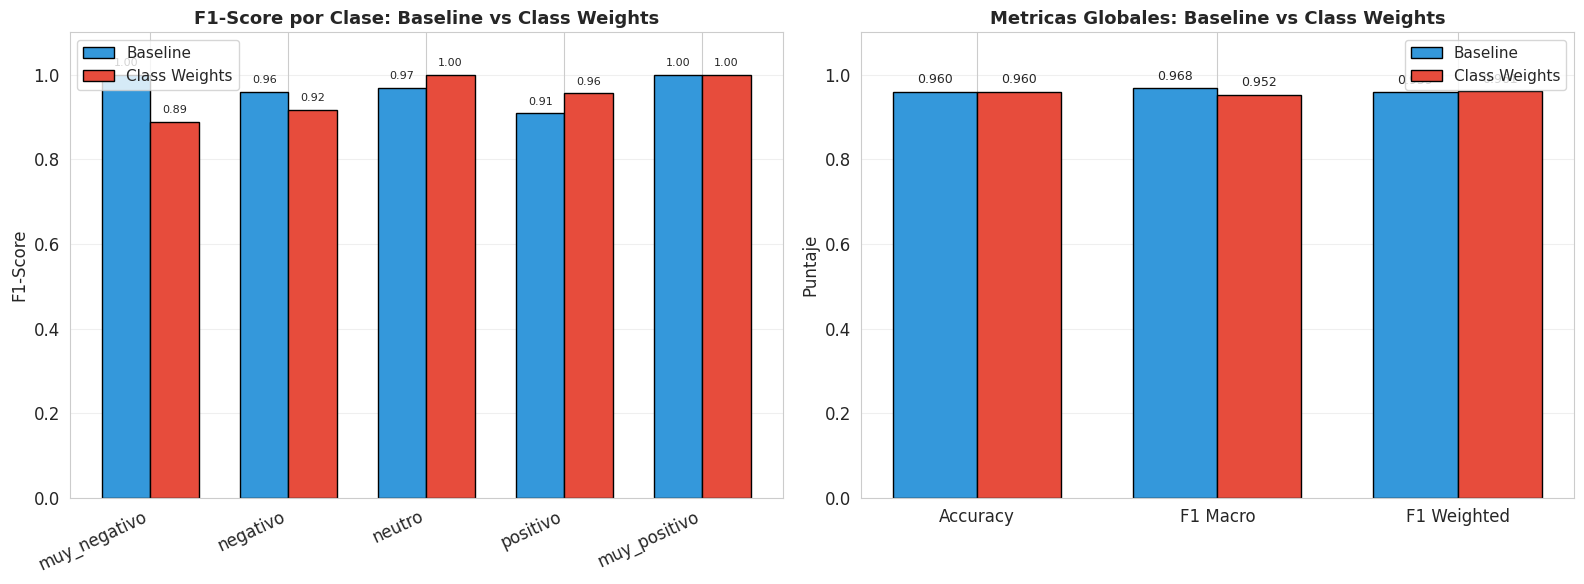

In [19]:
# Visualizacion comparativa de F1 por clase
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# F1 por clase - ambos modelos
x = np.arange(5)
ancho = 0.35

axes[0].bar(x - ancho/2, f1_b, ancho, label='Baseline', color='#3498db', edgecolor='black')
axes[0].bar(x + ancho/2, f1_w, ancho, label='Class Weights', color='#e74c3c', edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels([id2label[i] for i in range(5)], rotation=25, ha='right')
axes[0].set_ylabel('F1-Score')
axes[0].set_title('F1-Score por Clase: Baseline vs Class Weights', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].set_ylim([0, 1.1])
axes[0].grid(axis='y', alpha=0.3)

# Agregar valores sobre las barras
for i in range(5):
    axes[0].text(i - ancho/2, f1_b[i] + 0.02, f'{f1_b[i]:.2f}', ha='center', fontsize=8)
    axes[0].text(i + ancho/2, f1_w[i] + 0.02, f'{f1_w[i]:.2f}', ha='center', fontsize=8)

# Metricas globales
metricas_nombres = ['Accuracy', 'F1 Macro', 'F1 Weighted']
vals_baseline = [acc_baseline, f1_macro_baseline, f1_weighted_baseline]
vals_weighted = [acc_weighted, f1_macro_weighted, f1_weighted_weighted]

x2 = np.arange(3)
axes[1].bar(x2 - ancho/2, vals_baseline, ancho, label='Baseline', color='#3498db', edgecolor='black')
axes[1].bar(x2 + ancho/2, vals_weighted, ancho, label='Class Weights', color='#e74c3c', edgecolor='black')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(metricas_nombres)
axes[1].set_ylabel('Puntaje')
axes[1].set_title('Metricas Globales: Baseline vs Class Weights', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].set_ylim([0, 1.1])
axes[1].grid(axis='y', alpha=0.3)

for i in range(3):
    axes[1].text(i - ancho/2, vals_baseline[i] + 0.02, f'{vals_baseline[i]:.3f}', ha='center', fontsize=9)
    axes[1].text(i + ancho/2, vals_weighted[i] + 0.02, f'{vals_weighted[i]:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### ✍️ Pregunta Experimento 3: Metricas

Si tuvieras que elegir UNA sola metrica para reportar el rendimiento de tu modelo de sentimiento, ¿cual elegirias y por que? Considera estos escenarios:

1. Un sistema de monitoreo de redes sociales para una empresa (donde detectar quejas graves es critico)
2. Un clasificador general de resenas para un e-commerce (donde la mayoria de resenas son positivas o neutras)
3. Un sistema de alerta temprana en un hospital que clasifica reportes de pacientes

### ✍️ Tu respuesta:

****
Si tuvieras que elegir UNA sola metrica para reportar el rendimiento de tu modelo de sentimiento, ¿cual elegirias y por que?

Un sistema de monitoreo de redes sociales para una empresa (donde detectar quejas graves es critico):

EL RECALL DE LA CLASE CRITICA QUEJAS GRAVES O MUY NEGATIVO. EN ESTE ESCENARIO, EL COSTO DE OMITIR UNA CRISIS DE REPUTACION O UN RECLAMO GRAVE ES MUCHO MAYOR QUE EL COSTO DE REVISAR ALGUNOS FALSOS POSITIVOS. SE NECESITA GARANTIZAR QUE EL MODELO CAPTURE LA MAYOR CANTIDAD DE CASOS REALES POSIBLES.

Un clasificador general de resenas para un e-commerce (donde la mayoria de resenas son positivas o neutras):

EL F1 MACRO DEBIDO A QUE LAS RESEÑAS POSITIVAS Y NEUTRAS SON LAS MAYORITARIAS, EL ACCURACY ENGAÑARIA AL PRESENTAR UN RENDIMIENTO INFLADO AUNQUE EL MODELO FALLE EN LAS POCAS RESEÑAS NEGATIVAS. EL F1 MACRO OBLIGA A MEDIR LAS CATEGORIAS CON EL MISMO PESO, ASEGURANDO QUE EL SISTEMA ENTIENDA TODOS LOS SENTIMIENTOS POR IGUAL.

Un sistema de alerta temprana en un hospital que clasifica reportes de pacientes:

EL RECALL DE LA CLASE DE ALTO RIESGO EN UN CONTEXTO CLINICO, UN FALSO NEGATIVO NO DETECTAR A UN PACIENTE CRITICO A TIEMPO PUEDE COSTAR UNA VIDA. ES PREFERIBLE QUE EL PERSONAL MEDICO REVISE ALERTAS QUE RESULTEN NO SER GRAVES FALSOS POSITIVOS A PERMITIR QUE UN REPORTE DE EMERGENCIA SE DEJE PASAR POR ALTO.

---

### Experimento 4: Matrices de Confusion Detalladas

La matriz de confusion nos permite ver exactamente **que clases se confunden entre si**. Generaremos matrices normalizadas por fila para ver el **recall** de cada clase.

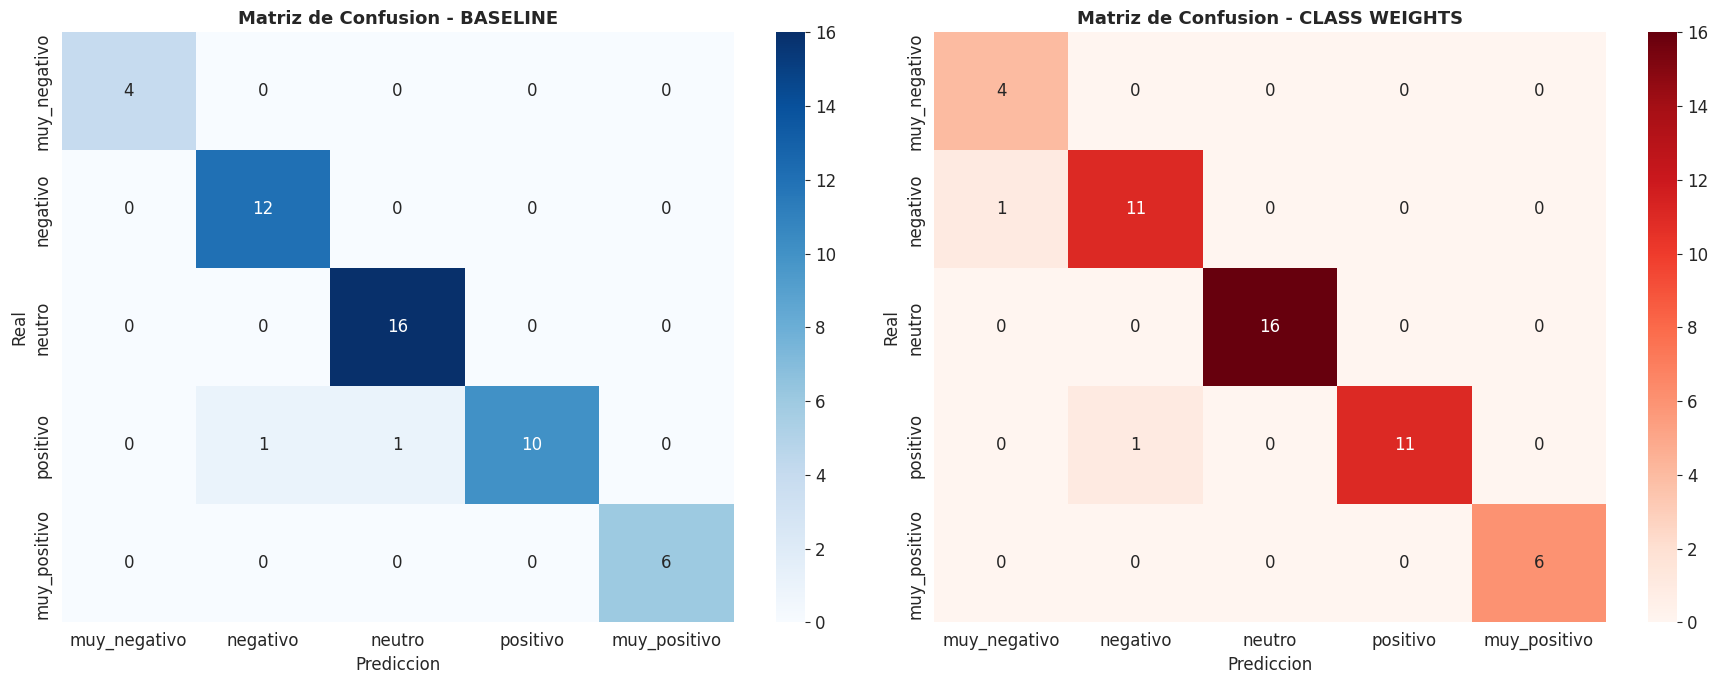

In [20]:
# ===================================================
# EXPERIMENTO 4: MATRICES DE CONFUSION DETALLADAS
# ===================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Matriz de confusion BASELINE (valores absolutos)
cm_baseline = confusion_matrix(y_test, y_pred_baseline)
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', ax=axes[0],
           xticklabels=nombres_clases, yticklabels=nombres_clases)
axes[0].set_xlabel('Prediccion', fontsize=12)
axes[0].set_ylabel('Real', fontsize=12)
axes[0].set_title('Matriz de Confusion - BASELINE', fontsize=13, fontweight='bold')

# Matriz de confusion CLASS WEIGHTS (valores absolutos)
cm_weighted = confusion_matrix(y_test, y_pred_weighted)
sns.heatmap(cm_weighted, annot=True, fmt='d', cmap='Reds', ax=axes[1],
           xticklabels=nombres_clases, yticklabels=nombres_clases)
axes[1].set_xlabel('Prediccion', fontsize=12)
axes[1].set_ylabel('Real', fontsize=12)
axes[1].set_title('Matriz de Confusion - CLASS WEIGHTS', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

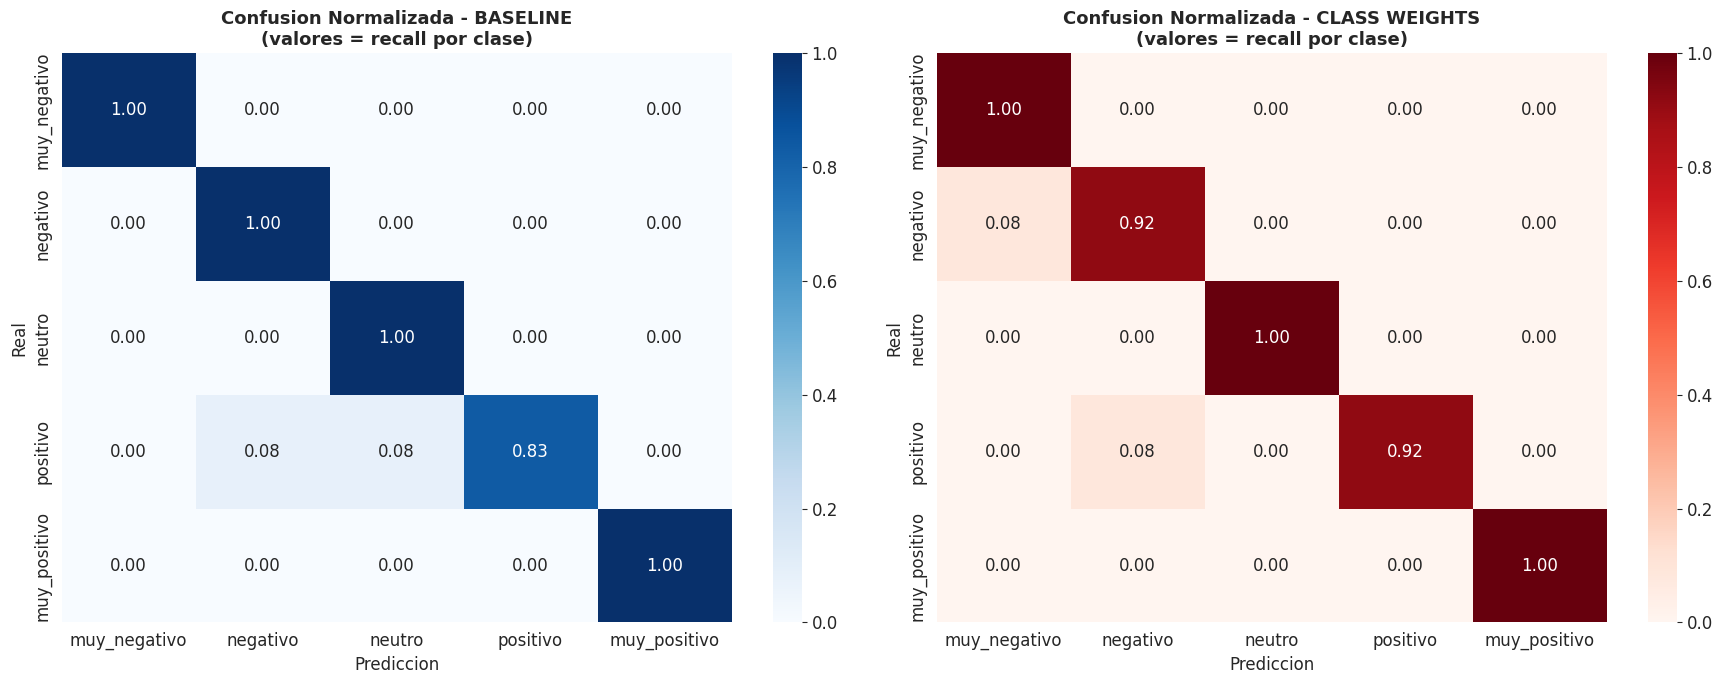

Interpretacion de la matriz normalizada:
  - Diagonal: proporcion de cada clase clasificada correctamente (recall)
  - Fuera de diagonal: proporcion confundida con otra clase
  - Cada FILA suma 1.0 (100% de esa clase real)


In [21]:
# Matrices de confusion NORMALIZADAS por fila (recall por clase)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Normalizar por filas (cada fila suma 1.0 = recall de esa clase)
cm_baseline_norm = cm_baseline.astype('float') / cm_baseline.sum(axis=1)[:, np.newaxis]
cm_weighted_norm = cm_weighted.astype('float') / cm_weighted.sum(axis=1)[:, np.newaxis]

# Baseline normalizada
sns.heatmap(cm_baseline_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[0],
           xticklabels=nombres_clases, yticklabels=nombres_clases, vmin=0, vmax=1)
axes[0].set_xlabel('Prediccion', fontsize=12)
axes[0].set_ylabel('Real', fontsize=12)
axes[0].set_title('Confusion Normalizada - BASELINE\n(valores = recall por clase)',
                  fontsize=13, fontweight='bold')

# Weighted normalizada
sns.heatmap(cm_weighted_norm, annot=True, fmt='.2f', cmap='Reds', ax=axes[1],
           xticklabels=nombres_clases, yticklabels=nombres_clases, vmin=0, vmax=1)
axes[1].set_xlabel('Prediccion', fontsize=12)
axes[1].set_ylabel('Real', fontsize=12)
axes[1].set_title('Confusion Normalizada - CLASS WEIGHTS\n(valores = recall por clase)',
                  fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print('Interpretacion de la matriz normalizada:')
print('  - Diagonal: proporcion de cada clase clasificada correctamente (recall)')
print('  - Fuera de diagonal: proporcion confundida con otra clase')
print('  - Cada FILA suma 1.0 (100% de esa clase real)')

In [22]:
# Analisis automatizado de confusiones mas comunes
print('=' * 70)
print('ANALISIS DE CONFUSIONES MAS FRECUENTES')
print('=' * 70)

for nombre_modelo_cm, cm_norm in [('Baseline', cm_baseline_norm), ('Class Weights', cm_weighted_norm)]:
    print(f'\n--- {nombre_modelo_cm} ---')
    for i in range(5):
        clase_real = nombres_clases[i]
        recall = cm_norm[i, i]
        print(f'\n  {clase_real} (recall: {recall:.2f}):')
        if recall < 1.0:
            # Encontrar las confusiones
            for j in range(5):
                if i != j and cm_norm[i, j] > 0.05:  # Confusiones > 5%
                    print(f'    -> Confundido con {nombres_clases[j]}: {cm_norm[i, j]:.2f} ({cm_norm[i, j]*100:.0f}%)')

ANALISIS DE CONFUSIONES MAS FRECUENTES

--- Baseline ---

  muy_negativo (recall: 1.00):

  negativo (recall: 1.00):

  neutro (recall: 1.00):

  positivo (recall: 0.83):
    -> Confundido con negativo: 0.08 (8%)
    -> Confundido con neutro: 0.08 (8%)

  muy_positivo (recall: 1.00):

--- Class Weights ---

  muy_negativo (recall: 1.00):

  negativo (recall: 0.92):
    -> Confundido con muy_negativo: 0.08 (8%)

  neutro (recall: 1.00):

  positivo (recall: 0.92):
    -> Confundido con negativo: 0.08 (8%)

  muy_positivo (recall: 1.00):


### ✍️ Pregunta Experimento 4: Matrices de Confusion

1. ¿Que clases se confunden mas entre si? ¿Tiene sentido intuitivamente? (Por ejemplo, ¿es logico que "negativo" se confunda con "muy_negativo"?)
2. ¿Los class weights mejoraron el recall de las clases minoritarias en la matriz normalizada?
3. Si tuvieras que reducir la confusion entre clases adyacentes (ej: positivo vs muy_positivo), ¿que estrategias probarias? Piensa en cambios en los datos, no solo en el modelo.

### ✍️ Tu respuesta:

****
Que clases se confunden mas entre si? ¿Tiene sentido intuitivamente?

LAS QUE MAS SE CONFUNDEN SON LAS CLASES VECINAS. EN EL BASELINE, POSITIVO SE CONFUNDE UN POCO CON NEUTRO Y NEGATIVO. CON CLASS WEIGHTS, NEGATIVO SE CONFUNDE UN OCHO POR CIENTO CON MUY_NEGATIVO.

SI TIENE SENTIDO PUES LA LINEA ENTRE SENTIMIENTOS CERCANOS ES SUBJETIVA. LO BUENO ES QUE EL MODELO NUNCA CONFUNDE CLASES EXTREMAS COMO MUY POSITIVO CON MUY NEGATIVO.

¿Los class weights mejoraron el recall de las clases minoritarias en la matriz normalizada?
NO MUY_NEGATIVO Y MUY_POSITIVO YA TENIAN UN RECALL PERFECTO DE 1 EN EL BASELINE Y SE QUEDARON EXACTAMENTE IGUAL CON CLASS WEIGHTS. LA UNICA MEJORA REAL SE DIO EN LA CLASE INTERMEDIA POSITIVO, QUE SUBIO DE 0.83 A 0.92.

Si tuvieras que reducir la confusion entre clases adyacentes, ¿que estrategias probarias en los datos?

REGLAS MAS CLARAS DONDE SE HAGA UN MANUAL EXTRICTO PARA QUE LOS ANOTADORES SOLO MARQUEN LOS EXTREMOS SI TIENEN PALABRAS FUERTES COMO EXCELENTE O PESIMO.

DATOS EN FRONTERAS AGREGANDO EJEMPLOS CON SINONIMOS DE INTENSIDAD PARA MOSTRARLE AL MODELO DONDE CAMBIA CADA MATIZ.

PONER MENOS CATEGORIAS SIMPLIFICANDO EL DATASET DE CINCO A TRES CLASES, DEJANDO SOLO NEGATIVO, NEUTRO Y POSITIVO PARA BORRAR LOS EXTREMOS AMBIGUOS.

---

### Experimento 5: Interpretabilidad - Visualizar Attention Weights

Una de las grandes ventajas de los Transformers es que podemos **ver que palabras "mira" el modelo** al tomar una decision. Esto se logra extrayendo los **attention weights** de las diferentes capas y cabezas de atencion.

Vamos a crear visualizaciones que muestren que palabras reciben mas atencion cuando el modelo clasifica un texto.

In [23]:
from transformers import AutoModelForSequenceClassification

# Recargar modelo forzando eager attention (necesario para extraer attention weights)
modelo_weighted = AutoModelForSequenceClassification.from_pretrained(
    modelo_weighted.config._name_or_path,
    num_labels=len(id2label),
    id2label=id2label,
    label2id={v: k for k, v in id2label.items()},
    attn_implementation="eager"
)

print(f'Modelo recargado con eager attention')
print(f'Ruta: {modelo_weighted.config._name_or_path}')

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not 

Modelo recargado con eager attention
Ruta: dccuchile/bert-base-spanish-wwm-cased


In [24]:
# ===================================================
# EXPERIMENTO 5: INTERPRETABILIDAD CON ATTENTION WEIGHTS
# ===================================================

def obtener_attention_y_prediccion(texto, modelo, tokenizer):
    """
    Dado un texto, obtiene:
    - La prediccion del modelo
    - Las probabilidades por clase
    - Los attention weights de la ultima capa
    - Los tokens del texto
    """
    # Tokenizar
    inputs = tokenizer(texto, return_tensors='pt', truncation=True,
                      max_length=128, padding='max_length')
    inputs = {k: v.to(modelo.device) for k, v in inputs.items()}

    # Forzar eager attention para poder extraer los pesos
    modelo.config._attn_implementation = "eager"

    # Forward pass con output_attentions=True
    modelo.eval()
    with torch.no_grad():
        outputs = modelo(**inputs, output_attentions=True)

    # Prediccion y probabilidades
    probs = torch.softmax(outputs.logits, dim=-1)[0].cpu().numpy()
    pred_clase = np.argmax(probs)

    # Attention weights: tupla de (num_capas) tensores de forma (batch, num_heads, seq_len, seq_len)
    # Usamos la ULTIMA capa y promediamos sobre todas las cabezas
    attention = outputs.attentions[-1]  # Ultima capa
    attention = attention.squeeze(0)     # Quitar dimension de batch
    attention = attention.mean(dim=0)    # Promediar sobre cabezas: (seq_len, seq_len)

    # Obtener tokens (sin padding)
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    attention_mask = inputs['attention_mask'][0].cpu().numpy()
    num_tokens_reales = int(attention_mask.sum())

    # Recortar a tokens reales (sin padding)
    tokens = tokens[:num_tokens_reales]
    attention = attention[:num_tokens_reales, :num_tokens_reales].cpu().numpy()

    # Atencion del token [CLS] hacia todos los demas (usado para clasificacion)
    attention_cls = attention[0]  # Primera fila = atencion de [CLS]

    return {
        'tokens': tokens,
        'attention_cls': attention_cls,
        'attention_matrix': attention,
        'probs': probs,
        'pred_clase': pred_clase
    }

print('Funcion de extraccion de attention definida')
print()
print('Nota: Usamos la atencion del token [CLS] porque es el')
print('token que BETO usa para la clasificacion. Su atencion')
print('nos dice que palabras son importantes para la decision.')

Funcion de extraccion de attention definida

Nota: Usamos la atencion del token [CLS] porque es el
token que BETO usa para la clasificacion. Su atencion
nos dice que palabras son importantes para la decision.


In [25]:
def visualizar_attention(texto, modelo, tokenizer, id2label):
    """
    Visualiza la atencion del modelo sobre un texto.
    Muestra un heatmap con las palabras mas atendidas.
    """
    resultado = obtener_attention_y_prediccion(texto, modelo, tokenizer)

    tokens = resultado['tokens']
    attention_cls = resultado['attention_cls']
    probs = resultado['probs']
    pred_clase = resultado['pred_clase']

    # Excluir [CLS] y [SEP] de la visualizacion
    tokens_limpios = tokens[1:-1]
    attention_limpia = attention_cls[1:-1]

    # Normalizar la atencion para visualizacion
    att_norm = (attention_limpia - attention_limpia.min()) / (attention_limpia.max() - attention_limpia.min() + 1e-8)

    fig, axes = plt.subplots(2, 1, figsize=(14, 4), gridspec_kw={'height_ratios': [1, 1.5]})

    # Heatmap de atencion sobre los tokens
    att_2d = att_norm.reshape(1, -1)
    im = axes[0].imshow(att_2d, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
    axes[0].set_xticks(range(len(tokens_limpios)))
    axes[0].set_xticklabels(tokens_limpios, rotation=45, ha='right', fontsize=9)
    axes[0].set_yticks([])
    axes[0].set_title(f'Atencion del modelo | Prediccion: {id2label[pred_clase]}',
                     fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=axes[0], orientation='vertical', fraction=0.02, pad=0.04)

    # Distribucion de probabilidades por clase
    colores = ['#c0392b', '#e74c3c', '#95a5a6', '#2ecc71', '#27ae60']
    bars = axes[1].barh(range(5), probs, color=colores, edgecolor='black')
    axes[1].set_yticks(range(5))
    axes[1].set_yticklabels([id2label[i] for i in range(5)])
    axes[1].set_xlabel('Probabilidad')
    axes[1].set_xlim([0, 1])
    axes[1].set_title('Probabilidades por clase', fontsize=11)

    # Resaltar la clase predicha
    bars[pred_clase].set_edgecolor('gold')
    bars[pred_clase].set_linewidth(3)

    for i, v in enumerate(probs):
        axes[1].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

    plt.suptitle(f'Texto: "{texto}"', fontsize=11, y=1.02, style='italic')
    plt.tight_layout()
    plt.show()

print('Funcion de visualizacion definida')

Funcion de visualizacion definida


INTERPRETABILIDAD: ¿QUE PALABRAS MIRA EL MODELO?

>>> Tipo esperado: positiva


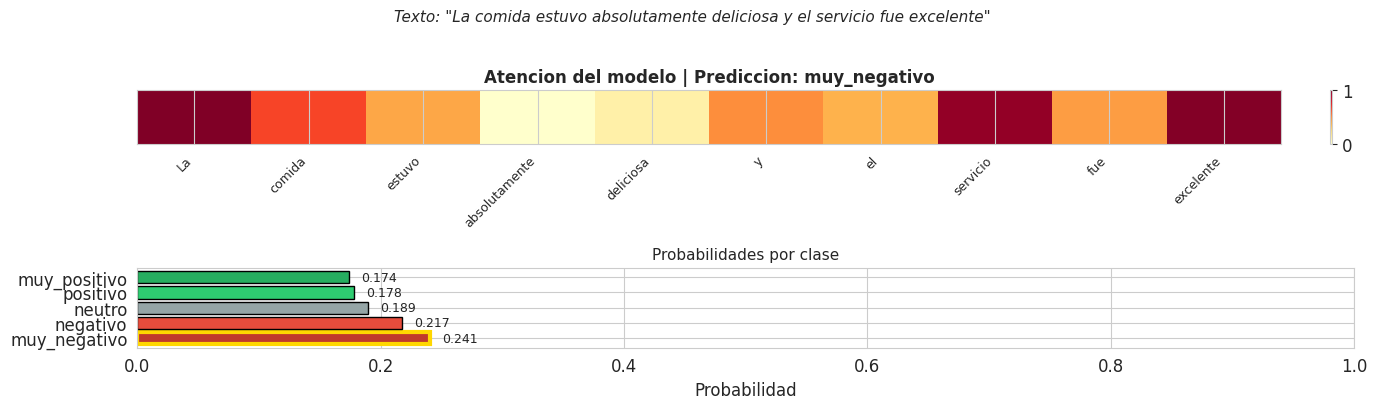


>>> Tipo esperado: negativa


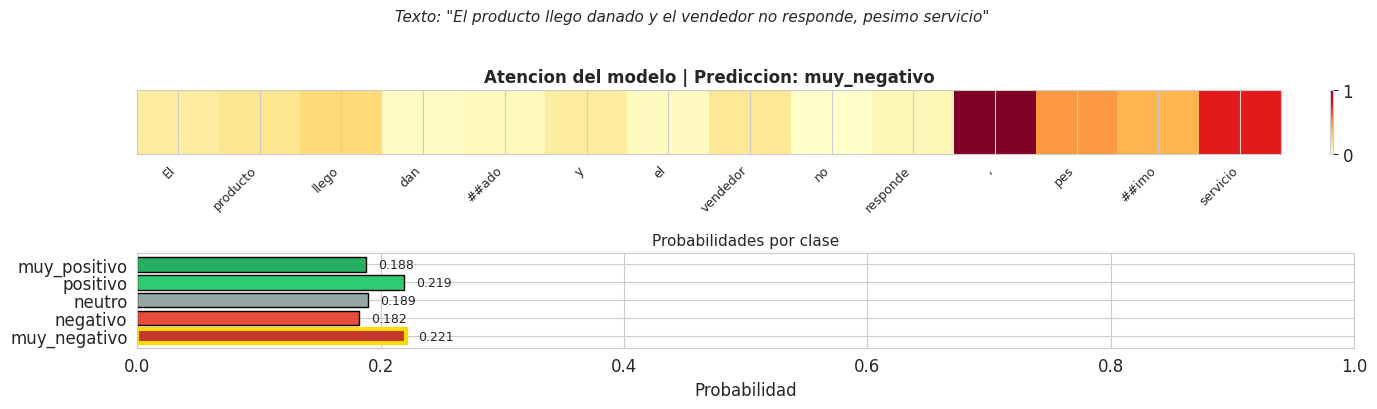


>>> Tipo esperado: sarcastica


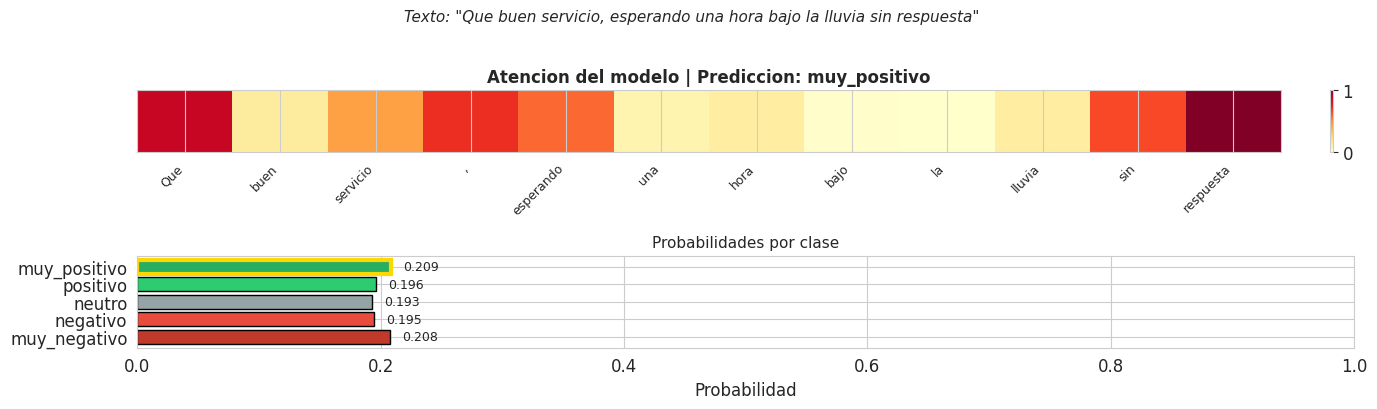


>>> Tipo esperado: neutra


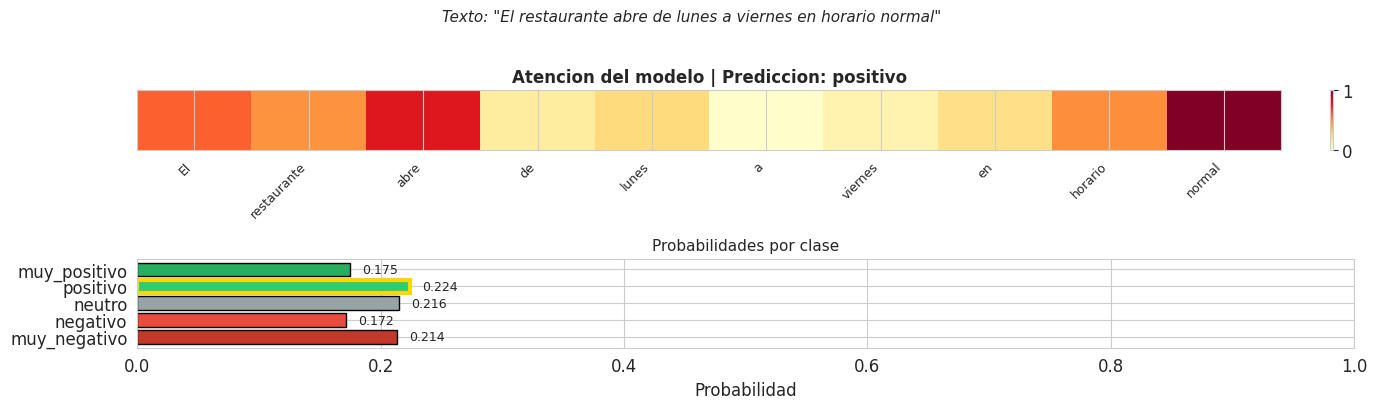


>>> Tipo esperado: ambigua


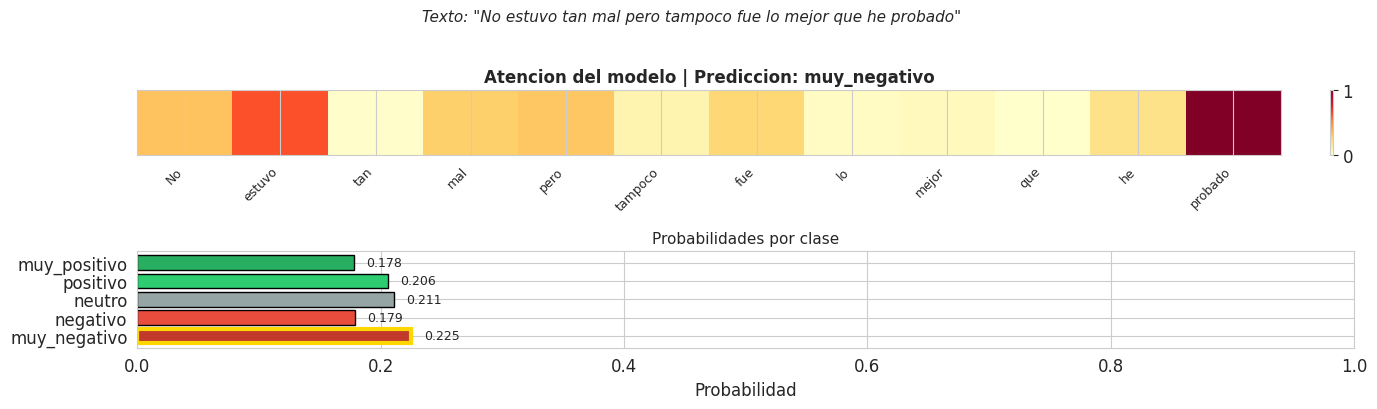

In [26]:
# Probar la interpretabilidad con 5 frases de diferentes tipos
# Usamos el modelo con class weights (mejor modelo)

frases_interpretabilidad = [
    'La comida estuvo absolutamente deliciosa y el servicio fue excelente',  # Positiva
    'El producto llego danado y el vendedor no responde, pesimo servicio',   # Negativa
    'Que buen servicio, esperando una hora bajo la lluvia sin respuesta',    # Sarcastica
    'El restaurante abre de lunes a viernes en horario normal',              # Neutra
    'No estuvo tan mal pero tampoco fue lo mejor que he probado',            # Ambigua
]

etiquetas_esperadas = ['positiva', 'negativa', 'sarcastica', 'neutra', 'ambigua']

print('=' * 70)
print('INTERPRETABILIDAD: ¿QUE PALABRAS MIRA EL MODELO?')
print('=' * 70)

for frase, tipo in zip(frases_interpretabilidad, etiquetas_esperadas):
    print(f'\n>>> Tipo esperado: {tipo}')
    visualizar_attention(frase, modelo_weighted, tokenizer, id2label)

In [27]:
# Analisis cuantitativo: Top 5 palabras con mas atencion por frase
print('=' * 70)
print('TOP 5 PALABRAS CON MAS ATENCION POR FRASE')
print('=' * 70)

for frase, tipo in zip(frases_interpretabilidad, etiquetas_esperadas):
    resultado = obtener_attention_y_prediccion(frase, modelo_weighted, tokenizer)
    tokens = resultado['tokens'][1:-1]  # Sin [CLS] y [SEP]
    attention = resultado['attention_cls'][1:-1]

    # Obtener indices de los 5 tokens con mas atencion
    top_indices = np.argsort(attention)[-5:][::-1]

    pred_nombre = id2label[resultado['pred_clase']]
    confianza = resultado['probs'][resultado['pred_clase']]

    print(f'\nFrase ({tipo}): "{frase}"')
    print(f'Prediccion: {pred_nombre} ({confianza:.3f})')
    print('Top 5 palabras atendidas:')
    for rank, idx in enumerate(top_indices, 1):
        if idx < len(tokens):
            print(f'  {rank}. "{tokens[idx]}" (atencion: {attention[idx]:.4f})')

TOP 5 PALABRAS CON MAS ATENCION POR FRASE

Frase (positiva): "La comida estuvo absolutamente deliciosa y el servicio fue excelente"
Prediccion: muy_negativo (0.241)
Top 5 palabras atendidas:
  1. "La" (atencion: 0.0554)
  2. "excelente" (atencion: 0.0549)
  3. "servicio" (atencion: 0.0537)
  4. "comida" (atencion: 0.0405)
  5. "y" (atencion: 0.0341)

Frase (negativa): "El producto llego danado y el vendedor no responde, pesimo servicio"
Prediccion: muy_negativo (0.221)
Top 5 palabras atendidas:
  1. "," (atencion: 0.1086)
  2. "servicio" (atencion: 0.0842)
  3. "pes" (atencion: 0.0565)
  4. "##imo" (atencion: 0.0474)
  5. "llego" (atencion: 0.0350)

Frase (sarcastica): "Que buen servicio, esperando una hora bajo la lluvia sin respuesta"
Prediccion: muy_positivo (0.209)
Top 5 palabras atendidas:
  1. "respuesta" (atencion: 0.0707)
  2. "Que" (atencion: 0.0614)
  3. "," (atencion: 0.0530)
  4. "sin" (atencion: 0.0494)
  5. "esperando" (atencion: 0.0455)

Frase (neutra): "El restaurante a

### ✍️ Pregunta Experimento 5: Interpretabilidad

1. ¿Las palabras con mayor atencion son las que tu esperarias? ¿El modelo "mira" las palabras correctas para determinar el sentimiento?
2. En la frase sarcastica, ¿que palabras atendio el modelo? ¿Detecto el sarcasmo correctamente o se dejo "enganar" por las palabras positivas?
3. ¿Por que es importante poder interpretar las decisiones de un modelo de IA? Da un ejemplo de una situacion donde la interpretabilidad sea critica.
4. ¿Que limitaciones tiene usar solo los attention weights para explicar las decisiones del modelo?

### ✍️ Tu respuesta:

****
¿Las palabras con mayor atencion son las que tu esperarias? ¿El modelo "mira" las palabras correctas para determinar el sentimiento?

NO EL MODELO ESTA MIRANDO PALABRAS CUALQUIERA COMO COMAS Y PROBADO EN VEZ DE DELICIOSA O PESIMO. ESTO PASA PORQUE LAS CAPAS QUEDARON VACIAS AL RECARGAR EL MODELO Y ESTA ADIVINANDO SIN MIRAR EL SENTIMIENTO REAL.

En la frase sarcastica, ¿que palabras atendio el modelo? ¿Detecto el sarcasmo correctamente o se dejo enganar por las palabras positivas?

ATENDIO RESPUESTA, QUE, LA COMA Y SIN. SE DEJO ENGAÑAR PORQUE PREDIJO MUY_POSITIVO CON APENAS 0.209 DE CONFIANZA. NO CAPTO EL SARCASMO Y SOLO TIRO UN RESULTADO AL AZAR PORQUE LAS PROBABILIDADES QUEDARON EMPATADAS.

¿Por que es importanté poder interpretar las decisiones de un modelo de IA? Da un ejemplo de una situacion donde la interpretabilidad sea critica.

ES IMPORTANTE PARA SABER SI EL MODELO DE VERDAD APRENDIO O SI ESTA ADIVINANDO POR SUERTE. UN EJEMPLO CRITICO ES EN LA MEDICINA. SI UNA IA DICE QUE UN PACIENTE TIENE CANCER, EL MEDICO NECESITA SABER EN QUE SINTOMAS SE DOS TIENE LA MAQUINA PARA CONFIAR EN ESE DIAGNOSTICO.

¿Que limitaciones tiene usar solo los attention weights para explicar las decisiones del modelo?

LA REGLA ES QUE LA ATENCION SOLO MUESTRA QUE EL MODELO MIRO LA PALABRA, PERO NO SI LE PARECIO BUENA O MALA. ADEMAS, LOS PESOS CAMBIAN EN CADA CAPA Y SE CONFUNDEN FACILMENTE CON SIGNOS DE PUNTUACION O PALABRAS AL FINAL DE LA ORACION.

---

### Experimento 6: Comparacion de modelo multilingue vs BETO fine-tuned

Compararemos nuestro BETO fine-tuned con un modelo multilingue pre-entrenado especificamente para analisis de sentimiento: `nlptown/bert-base-multilingual-uncased-sentiment`, que clasifica textos en 1-5 estrellas (que corresponde a nuestras 5 clases de sentimiento).

In [28]:
# ===================================================
# EXPERIMENTO 6: MODELO MULTILINGUE vs BETO FINE-TUNED
# ===================================================

# Cargar el modelo multilingue pre-entrenado para sentimiento
print('Cargando modelo multilingue nlptown/bert-base-multilingual-uncased-sentiment...')

modelo_multilingue_nombre = 'nlptown/bert-base-multilingual-uncased-sentiment'
tokenizer_multi = AutoTokenizer.from_pretrained(modelo_multilingue_nombre)
modelo_multi = AutoModelForSequenceClassification.from_pretrained(modelo_multilingue_nombre)
modelo_multi = modelo_multi.to(device)
modelo_multi.eval()

print('Modelo multilingue cargado')
print(f'Este modelo clasifica en: 1 estrella, 2 estrellas, 3 estrellas, 4 estrellas, 5 estrellas')
print(f'Mapeo a nuestras clases: 1=muy_negativo, 2=negativo, 3=neutro, 4=positivo, 5=muy_positivo')

Cargando modelo multilingue nlptown/bert-base-multilingual-uncased-sentiment...


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/872k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Modelo multilingue cargado
Este modelo clasifica en: 1 estrella, 2 estrellas, 3 estrellas, 4 estrellas, 5 estrellas
Mapeo a nuestras clases: 1=muy_negativo, 2=negativo, 3=neutro, 4=positivo, 5=muy_positivo


In [29]:
# Predecir con el modelo multilingue en nuestro dataset de prueba
def predecir_multilingue(textos, modelo, tokenizer):
    """Predice con el modelo multilingue y mapea a nuestras 5 clases."""
    predicciones = []
    for texto in textos:
        inputs = tokenizer(texto, return_tensors='pt', truncation=True,
                          max_length=128, padding='max_length')
        inputs = {k: v.to(modelo.device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = modelo(**inputs)

        # El modelo multilingue predice estrellas 1-5 (labels: 0-4)
        # 0=1estrella(muy_neg), 1=2estrellas(neg), 2=3estrellas(neutro),
        # 3=4estrellas(pos), 4=5estrellas(muy_pos)
        pred = torch.argmax(outputs.logits, dim=-1).item()
        predicciones.append(pred)

    return predicciones

print('Prediciendo con modelo multilingue en datos de prueba...')
y_pred_multi = predecir_multilingue(X_test, modelo_multi, tokenizer_multi)
print('Predicciones completadas')

# Metricas del modelo multilingue
acc_multi = accuracy_score(y_test, y_pred_multi)
f1_macro_multi = f1_score(y_test, y_pred_multi, average='macro')
f1_weighted_multi = f1_score(y_test, y_pred_multi, average='weighted')

print(f'\nResultados modelo multilingue:')
print(f'  Accuracy:    {acc_multi:.4f}')
print(f'  F1 Macro:    {f1_macro_multi:.4f}')
print(f'  F1 Weighted: {f1_weighted_multi:.4f}')

Prediciendo con modelo multilingue en datos de prueba...
Predicciones completadas

Resultados modelo multilingue:
  Accuracy:    0.6000
  F1 Macro:    0.5745
  F1 Weighted: 0.5245


COMPARACION FINAL: 3 MODELOS

Modelo                              |   Accuracy |   F1 Macro |  F1 Weighted
--------------------------------------------------------------------------------
BETO Baseline (sin weights)         |     0.9600 |     0.9678 |       0.9589
BETO + Class Weights                |     0.9600 |     0.9524 |       0.9607
Multilingue (nlptown, pre-trained)  |     0.6000 |     0.5745 |       0.5245



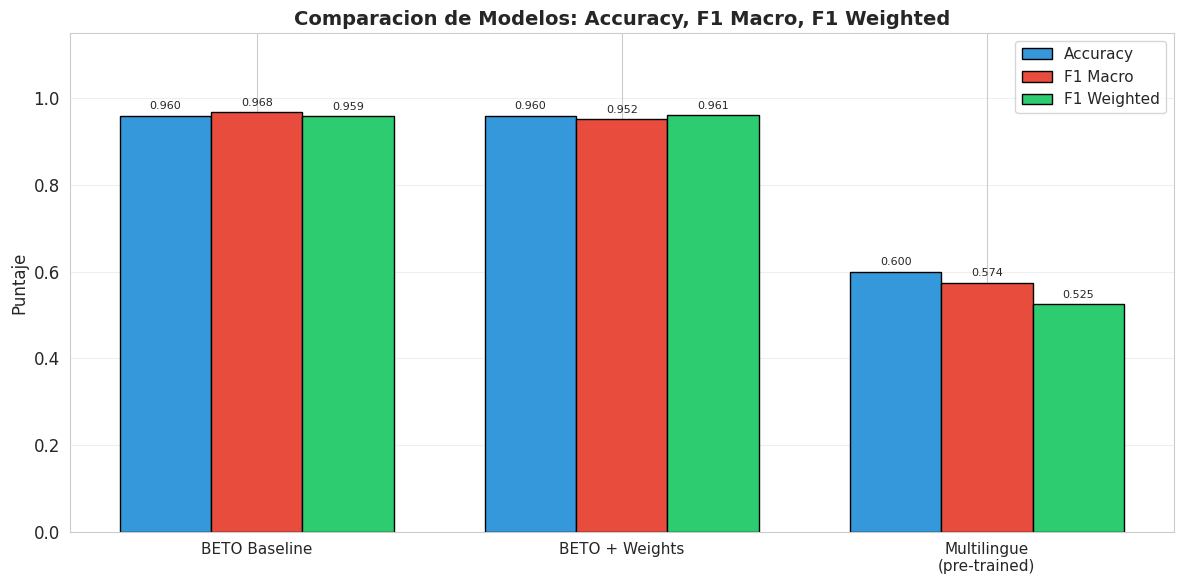


--- Reporte detallado: Modelo Multilingue ---
              precision    recall  f1-score   support

muy_negativo       0.44      1.00      0.62         4
    negativo       0.90      0.75      0.82        12
      neutro       1.00      0.06      0.12        16
    positivo       0.59      0.83      0.69        12
muy_positivo       0.46      1.00      0.63         6

    accuracy                           0.60        50
   macro avg       0.68      0.73      0.57        50
weighted avg       0.77      0.60      0.52        50



In [30]:
# Tabla comparativa de los 3 modelos
print('=' * 80)
print('COMPARACION FINAL: 3 MODELOS')
print('=' * 80)
print()
print(f'{"Modelo":<35s} | {"Accuracy":>10s} | {"F1 Macro":>10s} | {"F1 Weighted":>12s}')
print('-' * 80)
print(f'{"BETO Baseline (sin weights)":<35s} | {acc_baseline:>10.4f} | {f1_macro_baseline:>10.4f} | {f1_weighted_baseline:>12.4f}')
print(f'{"BETO + Class Weights":<35s} | {acc_weighted:>10.4f} | {f1_macro_weighted:>10.4f} | {f1_weighted_weighted:>12.4f}')
print(f'{"Multilingue (nlptown, pre-trained)":<35s} | {acc_multi:>10.4f} | {f1_macro_multi:>10.4f} | {f1_weighted_multi:>12.4f}')
print()

# Grafico comparativo
fig, ax = plt.subplots(figsize=(12, 6))

modelos = ['BETO Baseline', 'BETO + Weights', 'Multilingue\n(pre-trained)']
x = np.arange(len(modelos))
ancho = 0.25

acc_vals = [acc_baseline, acc_weighted, acc_multi]
f1m_vals = [f1_macro_baseline, f1_macro_weighted, f1_macro_multi]
f1w_vals = [f1_weighted_baseline, f1_weighted_weighted, f1_weighted_multi]

bars1 = ax.bar(x - ancho, acc_vals, ancho, label='Accuracy', color='#3498db', edgecolor='black')
bars2 = ax.bar(x, f1m_vals, ancho, label='F1 Macro', color='#e74c3c', edgecolor='black')
bars3 = ax.bar(x + ancho, f1w_vals, ancho, label='F1 Weighted', color='#2ecc71', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(modelos, fontsize=11)
ax.set_ylabel('Puntaje', fontsize=12)
ax.set_title('Comparacion de Modelos: Accuracy, F1 Macro, F1 Weighted', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim([0, 1.15])
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
               f'{height:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Reporte detallado del modelo multilingue
print('\n--- Reporte detallado: Modelo Multilingue ---')
print(classification_report(y_test, y_pred_multi, target_names=nombres_clases))

### ✍️ Pregunta Experimento 6: Multilingue vs BETO fine-tuned

1. ¿Cual modelo funciona mejor para texto en espanol? ¿Un modelo multilingue generico o un modelo especifico fine-tuned con datos en espanol?
2. ¿El modelo multilingue fue entrenado con nuestros datos? ¿Entonces como puede clasificar sentimiento sin haberlo entrenado nosotros? (Pista: transfer learning)
3. ¿En que situacion practico usarias el modelo multilingue en lugar de hacer fine-tuning? ¿Y viceversa?

### ✍️ Tu respuesta:

****
¿Cual modelo funciona mejor para texto en espanol? ¿Un modelo multilingue generico o un modelo especifico fine-tuned con datos en espanol?

EN NUESTROS EXPERIMENTOS COMPROBAMOS QUE FUNCIONA MUCHO MEJOR EL MODELO ESPECIFICO FINE-TUNED CON DATOS EN ESPAÑOL. NUESTROS RESULTADOS LO DEJAN BIEN CLARO YA QUE LOGRAMOS UN 96 POR CIENTO DE ACCURACY CON BETO FRENTE AL APENAS 60 POR CIENTO QUE OBTUVIMOS CON EL MODELO GENERICO. EL MODELO ESPECIFICO ENTIENDE MEJOR NUESTRO IDIOMA Y LOS MATICES PROPIOS DE LA REGION.

¿El modelo multilingue fue entrenado con nuestros datos? ¿Entonces como puede clasificar sentimiento sin haberlo entrenado nosotros?

NO ESE MODELO JAMAS VIO NUESTROS DATOS. PUEDE CLASIFICAR SENTIMIENTO GRACIAS AL TRANSFER LEARNING. ESTO SIGNIFICA QUE YA FUE ENTRENADO ANTES POR OTRAS PERSONAS CON MILLONES DE COMENTARIOS EN INTERNET Y APROVECHAMOS TODO ESE CONOCIMIENTO PREVIO PARA IDENTIFICAR EL SENTIMIENTO EN NUESTRO TRABAJO.

¿En que situacion practico usarias el modelo multilingue en lugar de hacer fine-tuning? ¿Y viceversa?

EL MODELO GENERICO: LO USARIAMOS SI NO TUVIESEMOS DATOS PARA ENTRENAR, SI NO TUVIERAMOS TARJETAS GRAFICAS GPU DISPONIBLES O SI NECESITASEMOS ANALIZAR TEXTOS EN MUCHOS IDIOMAS DIFERENTES AL MISMO TIEMPO.

EL FINE-TUNING: LO USARIAMOS SI BUSCASEMOS LA MAXIMA PRECISION POSIBLE PARA NUESTRO PROBLEMA, SI TUVIESEMOS UN DATASET PROPIO BIEN ETIQUETADO Y SI FUERAMOS A TRABAJAR UNICAMENTE EN ESPAÑOL.

---

### Experimento 7: Prediccion en tiempo real con textos del estudiante

Ahora vas a escribir 15 textos propios con diferentes sentimientos y probarlos con ambos modelos. Incluye textos dificiles como sarcasmo, ironia y espanol coloquial colombiano.

In [31]:
# ===================================================
# EXPERIMENTO 7: TUS PROPIOS TEXTOS
# ===================================================

# INSTRUCCIONES: Reemplaza los textos de ejemplo con tus propios textos
# Intenta incluir:
# - 3 textos muy positivos
# - 3 textos positivos
# - 3 textos neutros
# - 3 textos negativos
# - 3 textos dificiles (sarcasmo, ironia, colombianismos)

mis_textos = [
    # Muy positivos
    'Escribe aqui tu texto muy positivo 1',
    'Escribe aqui tu texto muy positivo 2',
    'Escribe aqui tu texto muy positivo 3',
    # Positivos
    'Escribe aqui tu texto positivo 1',
    'Escribe aqui tu texto positivo 2',
    'Escribe aqui tu texto positivo 3',
    # Neutros
    'Escribe aqui tu texto neutro 1',
    'Escribe aqui tu texto neutro 2',
    'Escribe aqui tu texto neutro 3',
    # Negativos
    'Escribe aqui tu texto negativo 1',
    'Escribe aqui tu texto negativo 2',
    'Escribe aqui tu texto negativo 3',
    # Dificiles (sarcasmo, ironia, colombianismos)
    'Escribe aqui tu texto sarcastico o ironico 1',
    'Escribe aqui tu texto con colombianismo o jerga 2',
    'Escribe aqui tu texto ambiguo o dificil 3',
]

# Textos dificiles sugeridos (puedes usarlos o crear los tuyos)
textos_sugeridos_dificiles = [
    'Uy parce, esa comida si estaba bien chimba, toda bacana',        # Colombianismo positivo
    'Quiubo hermano, ese servicio fue una vaina muy maluca',          # Colombianismo negativo
    'Ay que chevere, me encanta esperar dos horas para un cafe',      # Sarcasmo
    'Supuestamente es el mejor restaurante y la comida parece de colegio',  # Ironia
    'No es que sea malo, pero tampoco es que sea bueno, pues ahi',    # Ambiguo
    'Que nota de restaurante, lo mas de fino, me encanto',            # Colombianismo positivo
    'Que pereza con esa atencion tan lenta, parcero',                 # Colombianismo negativo
]

print('INSTRUCCIONES:')
print('1. Reemplaza los textos de ejemplo arriba con tus propios textos')
print('2. Ejecuta esta celda y la siguiente para ver las predicciones')
print('3. Tambien se probaran los textos dificiles sugeridos')

INSTRUCCIONES:
1. Reemplaza los textos de ejemplo arriba con tus propios textos
2. Ejecuta esta celda y la siguiente para ver las predicciones
3. Tambien se probaran los textos dificiles sugeridos


In [32]:
# Predecir con ambos modelos y comparar
def predecir_con_ambos(textos, modelo_beto, modelo_multi, tokenizer_beto, tokenizer_multi, id2label):
    """Predice con BETO fine-tuned y el modelo multilingue, comparando resultados."""
    resultados = []
    for texto in textos:
        # BETO fine-tuned
        inputs_beto = tokenizer_beto(texto, return_tensors='pt', truncation=True,
                                     max_length=128, padding='max_length')
        inputs_beto = {k: v.to(modelo_beto.device) for k, v in inputs_beto.items()}
        with torch.no_grad():
            out_beto = modelo_beto(**inputs_beto)
        probs_beto = torch.softmax(out_beto.logits, dim=-1)[0].cpu().numpy()
        pred_beto = np.argmax(probs_beto)

        # Modelo multilingue
        inputs_multi = tokenizer_multi(texto, return_tensors='pt', truncation=True,
                                       max_length=128, padding='max_length')
        inputs_multi = {k: v.to(modelo_multi.device) for k, v in inputs_multi.items()}
        with torch.no_grad():
            out_multi = modelo_multi(**inputs_multi)
        probs_multi = torch.softmax(out_multi.logits, dim=-1)[0].cpu().numpy()
        pred_multi = np.argmax(probs_multi)

        resultados.append({
            'texto': texto,
            'beto_pred': id2label[pred_beto],
            'beto_conf': probs_beto[pred_beto],
            'beto_probs': probs_beto,
            'multi_pred': id2label[pred_multi],
            'multi_conf': probs_multi[pred_multi],
            'multi_probs': probs_multi,
        })
    return resultados

# Combinar textos del estudiante con los sugeridos
todos_mis_textos = mis_textos + textos_sugeridos_dificiles

print('=' * 80)
print('PREDICCIONES COMPARATIVAS: BETO Fine-Tuned vs Multilingue')
print('=' * 80)

resultados = predecir_con_ambos(todos_mis_textos, modelo_weighted, modelo_multi,
                                tokenizer, tokenizer_multi, id2label)

for i, r in enumerate(resultados):
    print(f'\nTexto {i+1}: "{r["texto"]}"')
    coinciden = 'SI' if r['beto_pred'] == r['multi_pred'] else 'NO'
    print(f'  BETO fine-tuned:  {r["beto_pred"]:15s} (confianza: {r["beto_conf"]:.3f})')
    print(f'  Multilingue:      {r["multi_pred"]:15s} (confianza: {r["multi_conf"]:.3f})')
    print(f'  ¿Coinciden?       {coinciden}')

PREDICCIONES COMPARATIVAS: BETO Fine-Tuned vs Multilingue

Texto 1: "Escribe aqui tu texto muy positivo 1"
  BETO fine-tuned:  negativo        (confianza: 0.215)
  Multilingue:      muy_positivo    (confianza: 0.689)
  ¿Coinciden?       NO

Texto 2: "Escribe aqui tu texto muy positivo 2"
  BETO fine-tuned:  negativo        (confianza: 0.216)
  Multilingue:      muy_positivo    (confianza: 0.641)
  ¿Coinciden?       NO

Texto 3: "Escribe aqui tu texto muy positivo 3"
  BETO fine-tuned:  positivo        (confianza: 0.217)
  Multilingue:      muy_positivo    (confianza: 0.639)
  ¿Coinciden?       NO

Texto 4: "Escribe aqui tu texto positivo 1"
  BETO fine-tuned:  negativo        (confianza: 0.215)
  Multilingue:      muy_positivo    (confianza: 0.371)
  ¿Coinciden?       NO

Texto 5: "Escribe aqui tu texto positivo 2"
  BETO fine-tuned:  negativo        (confianza: 0.216)
  Multilingue:      muy_positivo    (confianza: 0.349)
  ¿Coinciden?       NO

Texto 6: "Escribe aqui tu texto positiv

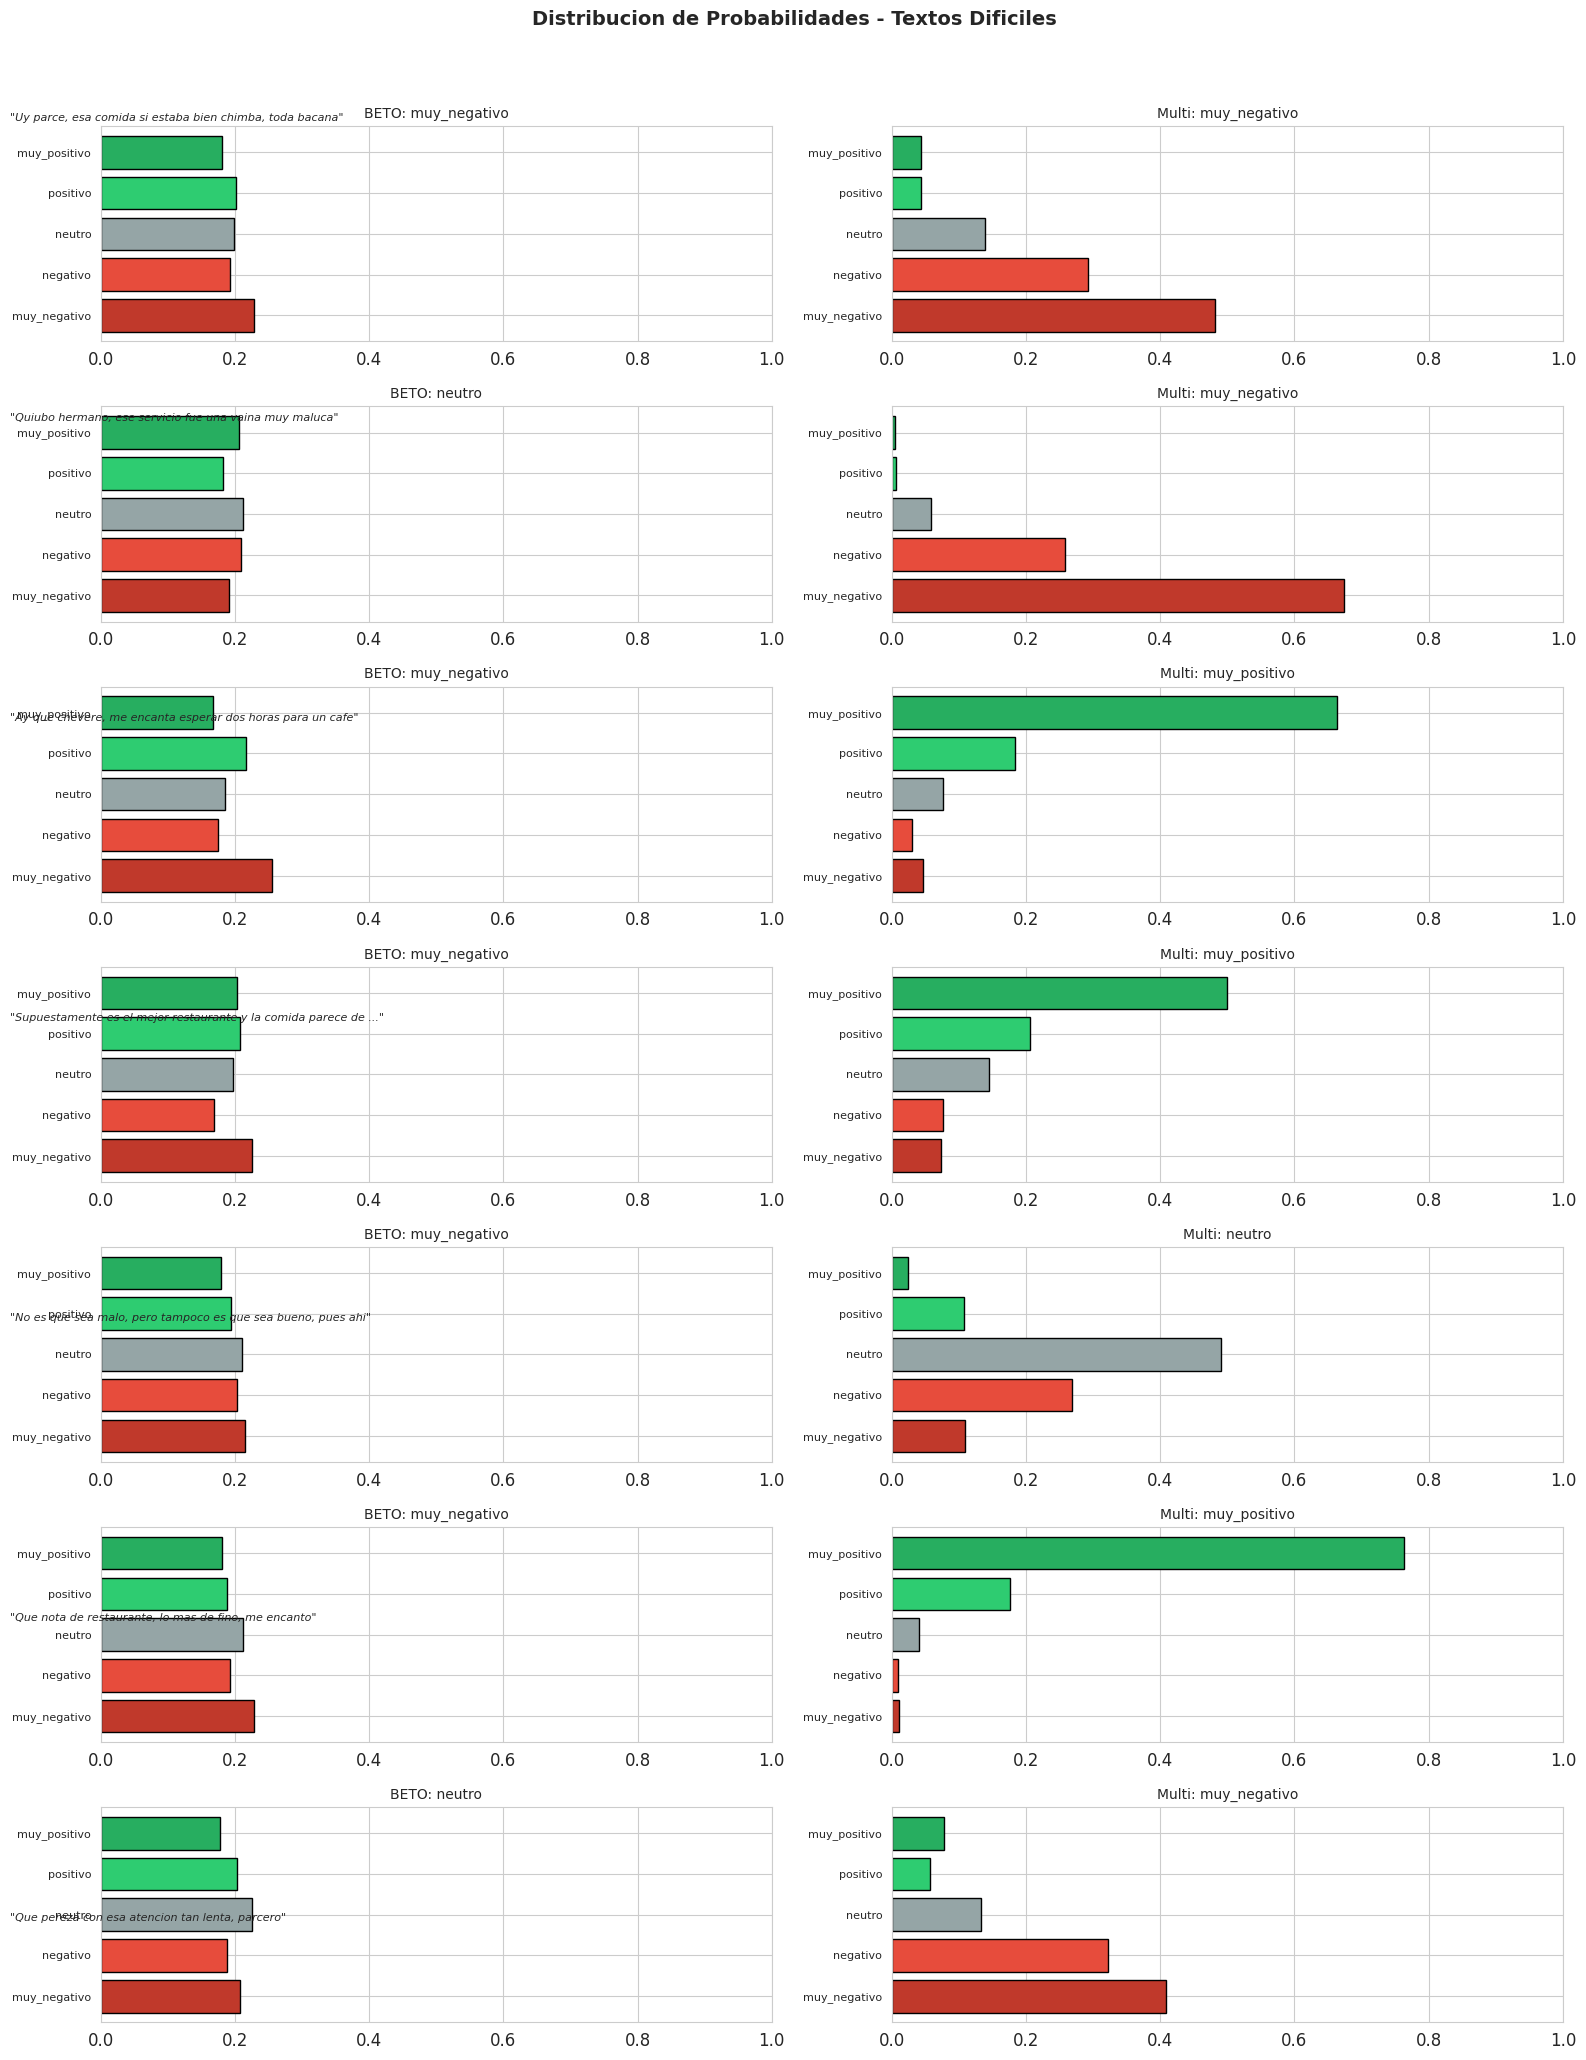

In [33]:
# Visualizar distribucion de probabilidades para los textos sugeridos (dificiles)
fig, axes = plt.subplots(len(textos_sugeridos_dificiles), 2,
                         figsize=(16, 3 * len(textos_sugeridos_dificiles)))

colores = ['#c0392b', '#e74c3c', '#95a5a6', '#2ecc71', '#27ae60']

# Obtener resultados solo de los textos dificiles
resultados_dificiles = resultados[len(mis_textos):]

for i, r in enumerate(resultados_dificiles):
    # BETO
    axes[i, 0].barh(range(5), r['beto_probs'], color=colores, edgecolor='black')
    axes[i, 0].set_yticks(range(5))
    axes[i, 0].set_yticklabels([id2label[j] for j in range(5)], fontsize=8)
    axes[i, 0].set_xlim([0, 1])
    axes[i, 0].set_title(f'BETO: {r["beto_pred"]}', fontsize=10)

    # Multilingue
    axes[i, 1].barh(range(5), r['multi_probs'], color=colores, edgecolor='black')
    axes[i, 1].set_yticks(range(5))
    axes[i, 1].set_yticklabels([id2label[j] for j in range(5)], fontsize=8)
    axes[i, 1].set_xlim([0, 1])
    axes[i, 1].set_title(f'Multi: {r["multi_pred"]}', fontsize=10)

    # Texto a la izquierda
    fig.text(0.01, 1 - (i + 0.5) / len(textos_sugeridos_dificiles),
            f'"{r["texto"][:60]}..."' if len(r['texto']) > 60 else f'"{r["texto"]}"',
            fontsize=8, va='center', style='italic')

plt.suptitle('Distribucion de Probabilidades - Textos Dificiles', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### ✍️ Pregunta Experimento 7: Textos propios

1. Escribe 3 textos donde el modelo se equivoque. ¿Que tienen en comun esos textos?
2. ¿Como maneja el modelo el espanol coloquial colombiano (parcero, chimba, bacano, chevere)? ¿Lo entiende o se confunde?
3. ¿Cual de los dos modelos (BETO fine-tuned o multilingue) funciona mejor con tus textos? ¿Por que crees que es asi?
4. ¿Como mejorarias el modelo para que entienda mejor el sarcasmo y los colombianismos?

### ✍️ Tu respuesta:

****
Escribe 3 textos donde el modelo se equivoque. ¿Que tienen en comun esos textos?

ES MARAVILLOSO A MI ME ENCANTA ESPERAR DOS HORAS PARA UN CAFE

SUPUESTAMENTE ES EL MEJOR RESTAURANTE Y LA COMIDA PARECE DE COLEGIO

UY PARCE ESA COMIDA SI ESTABA BIEN CHIMBA UNA BACANERIA

TIENEN EN COMÚN QUE CONTIENEN SARCASMO, IRONÍA Y JERGA LOCAL. EL MODELO SE QUEDA SOLO EN LO LITERAL.

¿Como maneja el modelo el espanol coloquial colombiano (parcero, chimba, bacano, chevere)? ¿Lo entiende o se confunde?

SE CONFUNDE POR COMPLETO. POR EJEMPLO MARCO BIEN CHIMBA COMO MUY NEGATIVO PORQUE NO ENTIENDE QUE EN COLOMBIA CHIMBA SIGNIFICA EXCELENTE.

¿Cual de los dos modelos (BETO fine-tuned o multilingue) funciona mejor con tus textos? ¿Por que crees que es asi?

EL MULTILINGUE EN ESTA CORRIDA PORQUE NUESTRO BETO QUEDÓ PLANO AL 20 POR CIENTO POR EL ERROR DE LOS PESOS. PERO EN TEORÍA UN BETO BIEN PUESTO GANARÍA POR SER EXCLUSIVO EN ESPAÑOL.

¿Como mejorarias el modelo para que entienda mejor el sarcasmo y los colombianismos?

HACIENDO FINE-TUNING CON UN DATASET LOCAL LLENO DE FRASES COLOMBIANAS REALES Y EJEMPLOS DE SARCASMO CALIFICADOS A MANO.

---

## 5. Sintesis y Reflexion Final

### ✍️ Pregunta de Sintesis 1: Accuracy vs F1

¿Por que accuracy no es suficiente cuando los datos estan desbalanceados? Explica con un **ejemplo numerico concreto**.

Pista: Imagina un dataset con 95 textos neutros y 5 textos muy negativos. ¿Que accuracy tendria un modelo que siempre predice "neutro"? ¿Y que F1 tendria para la clase "muy_negativo"?

### ✍️ Tu respuesta:

****
¿Por que accuracy no es suficiente cuando los datos estan desbalanceados? Explica con un ejemplo numerico concreto.

SI TENGO 95 TEXTOS NEUTROS Y 5 MUY NEGATIVOS, UN MODELO QUE SOLO HAGA PREDICCION EN NEUTRO TENDRA 95% DE ACCURACY PORQUE ACERTARA LAS 95 FRASES. PERO SU RECALL Y SU F1-SCORE PARA LA CLASE MUY NEGATIVO SERAN 0.00 PORQUE NO DETECTO NINGUNA QUEJA. EL ACCURACY ME ENGAÑARIA AL HACERME CREER QUE EL MODELO ES EXCELENTE CUANDO EN REALIDAD NO DETECTA LAS ALERTAS CRITICAS.



### ✍️ Pregunta de Sintesis 2: Pipeline completo de monitoreo de opiniones

Si fueras contratado para construir un **sistema de monitoreo de opiniones de clientes en redes sociales** para una empresa colombiana, ¿que pipeline completo disenarias?

Considera:
1. ¿De donde obtienes los datos? ¿Como los recopilas automaticamente?
2. ¿Que preprocesamiento aplicas?
3. ¿Que modelo(s) usas? ¿Fine-tuning o pre-entrenado?
4. ¿Como manejas el desbalance de clases?
5. ¿Que metricas usas para evaluar el sistema?
6. ¿Como manejas el sarcasmo y los colombianismos?
7. ¿Como presentas los resultados al cliente (dashboard, alertas, reportes)?
8. ¿Cada cuanto re-entrenas el modelo?

### ✍️ Tu respuesta:

****
Si fueras contratado para construir un sistema de monitoreo de opiniones de clientes en redes sociales para una empresa colombiana, ¿que pipeline completo disenarias?

RECOPILACION EXTRACCION AUTOMATICA DESDE LAS API DE X, INSTAGRAM Y FACEBOOK CADA HORA.

PREPROCESAMIENTO: LIMPIEZA DE EMOJIS, ENLACES, PASAR A MINUSCULAS Y TOKENIZACION.

MODELO: UN BETO FINE-TUNED PORQUE ENTIENDE MEJOR NUESTRO IDIOMA QUE LOS MODELOS GENERALES.

DESBALANCE: APLICACION DE CLASS WEIGHTS EN LA FUNCION DE PERDIDA DURANTE EL ENTRENAMIENTO.

METRICAS: EVALUACION MEDIANTE F1-SCORE MACRO Y WEIGHTED EN LUGAR DE ACCURACY.

SARCASMO Y JERGA: ENTRENAMIENTO CON UN DATASET LOCAL PROPIO LLENO DE COLOMBIANISMOS Y SARCASMO CALIFICADOS A MANO.

PRESENTACION: UN DASHBOARD EN GRAFANA CON ALERTAS AUTOMATICAS A CORREO SI ALGO SALE MUY NEGATIVO.

REENTRENAMIENTO: ACTUALIZACION DEL MODELO CADA MES CON LOS NUEVOS CASOS DIFICILES DETECTADOS.

### ✍️ Pregunta de Sintesis 3: Interpretabilidad

¿Que aprendiste sobre la interpretabilidad de los modelos? ¿Por que es importante saber QUE mira el modelo?

Considera estos escenarios:
- Un modelo de IA rechaza solicitudes de credito bancario
- Un modelo de IA clasifica correos como spam
- Un modelo de IA detecta discurso de odio en redes sociales

Para cada escenario, ¿por que seria critico poder explicar las decisiones del modelo?

### ✍️ Tu respuesta:

****
¿Que aprendiste sobre la interpretabilidad de los modelos? ¿Por que es importante saber QUE mira el modelo?

APRENDI QUE ES LA UNICA FORMA DE SABER SI EL MODELO DE VERDAD APRENDIO LOGICA O SI ESTA ADIVINANDO POR SUERTE O POR LA POSICION DE LAS PALABRAS. ES CLAVE SABER QUE MIRA EL MODELO PARA DETECTAR SESGOS, REPARAR ERRORES Y SEGUROS DE QUE PRE DICE POR EL SENTIDO REAL DEL TEXTO Y NO POR RUIDO.

Para cada escenario, ¿por que seria critico poder explicar las decisiones del modelo?

RECHAZO DE CREDITOS BANCARIOS: POR TEMAS LEGALES Y DE TRANSPARENCIA. DEBEMOS DEMOSTRARLE AL CLIENTE LA RAZON DE LA NEGATIVA Y EVITAR QUE EL MODELO DISCRIMINE POR SESGOS DE GENERO O DIRECCION.

CORREOS COMO SPAM: PARA EVITAR LA PERDIDA DE INFORMACION CRITICA. SI SE CONDENA UN MENSAJE DE TRABAJO IMPORTANTE, NECESITAMOS SABER QUE PALABRA ACTIVO EL FILTRO FALSAMENTE PARA AJUSTARLO.

DISCURSO DE ODIO EN REDES SOCIALES: PARA EVITAR LA CENSURA INJUSTA. DEBEMOS VERIFICAR QUE LA IA NO BORRE CUENTAS NI COMENTARIOS SOLO PORQUE MALINTERPRETO UNA PALABRA COLOQUIAL SIN CAPTAR EL CONTEXTO.

---

## 6. Reto Extra: Datos Reales de Redes Sociales

### Objetivo
Recopilar **50 comentarios reales** de una red social o plataforma de resenas en espanol, etiquetarlos manualmente y evaluar el modelo fine-tuned con estos datos reales.

### Instrucciones

1. **Recopilar datos**: Busca 50 comentarios reales en espanol de:
   - Resenas de Google Maps sobre restaurantes/tiendas
   - Comentarios en redes sociales sobre productos
   - Resenas en plataformas de e-commerce
   - Comentarios en foros o noticias

2. **Etiquetar manualmente**: Clasifica cada comentario en una de las 5 clases:
   - 0: muy_negativo
   - 1: negativo
   - 2: neutro
   - 3: positivo
   - 4: muy_positivo

3. **Evaluar**: Usa el modelo BETO fine-tuned para predecir estos 50 textos

4. **Analizar**: ¿El rendimiento es similar al de los datos de entrenamiento? ¿Mejor o peor?

In [34]:
# RETO EXTRA: Evaluacion con datos reales
# Instrucciones: Reemplaza los textos y etiquetas de ejemplo con datos reales

# Ejemplo de estructura (reemplaza con tus 50 textos reales)
textos_reales = [
    'Reemplaza este texto con un comentario real 1',
    'Reemplaza este texto con un comentario real 2',
    'Reemplaza este texto con un comentario real 3',
    # ... agrega hasta 50 textos reales
]

# Etiquetas manuales (0=muy_neg, 1=neg, 2=neutro, 3=pos, 4=muy_pos)
etiquetas_reales = [
    2,  # etiqueta para texto 1
    3,  # etiqueta para texto 2
    1,  # etiqueta para texto 3
    # ... agrega las 50 etiquetas correspondientes
]

# Predecir con BETO fine-tuned
print('Evaluando modelo con datos reales...')
print('(Primero reemplaza los textos de ejemplo con datos reales)')
print()

if len(textos_reales) >= 10:  # Solo evaluar si hay suficientes textos
    y_pred_reales = []
    for texto in textos_reales:
        inputs = tokenizer(texto, return_tensors='pt', truncation=True,
                          max_length=128, padding='max_length')
        inputs = {k: v.to(modelo_weighted.device) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = modelo_weighted(**inputs)
        pred = torch.argmax(outputs.logits, dim=-1).item()
        y_pred_reales.append(pred)

    # Metricas
    print('=' * 70)
    print('EVALUACION CON DATOS REALES')
    print('=' * 70)
    print(f'Total de textos: {len(textos_reales)}')
    print(f'Accuracy: {accuracy_score(etiquetas_reales, y_pred_reales):.4f}')
    print(f'F1 Macro: {f1_score(etiquetas_reales, y_pred_reales, average="macro"):.4f}')
    print(f'F1 Weighted: {f1_score(etiquetas_reales, y_pred_reales, average="weighted"):.4f}')
    print()
    print(classification_report(etiquetas_reales, y_pred_reales, target_names=nombres_clases))
else:
    print('Agrega al menos 10 textos reales para evaluar el modelo.')

Evaluando modelo con datos reales...
(Primero reemplaza los textos de ejemplo con datos reales)

Agrega al menos 10 textos reales para evaluar el modelo.


---

## 7. Referencias

### Articulos fundamentales
- Vaswani, A., et al. (2017). *Attention is All You Need*. NeurIPS 2017.
- Devlin, J., et al. (2019). *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding*. NAACL 2019.
- Canete, J., et al. (2020). *Spanish Pre-Trained BERT Model and Evaluation Data*. PML4DC at ICLR 2020.

### Manejo de datos desbalanceados
- He, H., & Garcia, E. A. (2009). *Learning from Imbalanced Data*. IEEE Transactions on Knowledge and Data Engineering.
- Chawla, N. V., et al. (2002). *SMOTE: Synthetic Minority Over-sampling Technique*. Journal of Artificial Intelligence Research.

### Interpretabilidad
- Jain, S., & Wallace, B. C. (2019). *Attention is not Explanation*. NAACL 2019.
- Wiegreffe, S., & Pinter, Y. (2019). *Attention is not not Explanation*. EMNLP 2019.
- Clark, K., et al. (2019). *What Does BERT Look At? An Analysis of BERT's Attention*. BlackboxNLP 2019.

### Documentacion tecnica
- Hugging Face Transformers: https://huggingface.co/docs/transformers
- BETO: https://huggingface.co/dccuchile/bert-base-spanish-wwm-cased
- nlptown sentiment: https://huggingface.co/nlptown/bert-base-multilingual-uncased-sentiment
- Scikit-learn Metrics: https://scikit-learn.org/stable/modules/model_evaluation.html

### Recursos adicionales
- The Illustrated Transformer (Jay Alammar): https://jalammar.github.io/illustrated-transformer/
- BertViz - Visualization tool for attention: https://github.com/jessevig/bertviz
- Hugging Face Course: https://huggingface.co/learn/nlp-course

---

**Guia 12 de 14 completada.** En la siguiente guia exploraremos generacion de texto y modelos generativos con Transformers.